<h1>NYC Rent Affordability Investigation:<br>NYC Gentrification ML Analysis</h1>

This is an investigation of rent affordability in NYC using neighborhood-level and borough-level from 2012-2022. 

I am using median rent data from the [Streeteasy Dashboard](https://streeteasy.com/blog/data-dashboard/), and median income data from the [U.S. Census American Community Survey](https://www.census.gov/programs-surveys/acs/data.html).

Here, I'll be using sci-kit learn to conduct unsupervised learning to create clusters of NYC neighborhoods based on Gentrification and Affordability indicators. 

This will give us insight into which phase of gentrification each neighborhood falls into.

# Importing packages and modules

In [1]:
# loading in custom utils
import utils.streeteasy_data_tools as st 
import utils.gentrification_tools as gt

In [57]:
import os
import pandas as pd
import numpy as np
# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
# postgres connection and analyses
import json
from google.cloud import bigquery
from google.oauth2 import service_account
# modeling/estimates
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
# organization
import warnings
warnings.filterwarnings('ignore')

# Importing relevant data from a BigQuery Postgres Database

In [3]:
# configure Big Query connection
PROJECT_ID = "rent-affordability"
DATASET_ID = "nyc_analysis"
service_account_info = json.loads(os.environ["GOOGLE_CREDENTIALS_JSON"])
credentials = service_account.Credentials.from_service_account_info(service_account_info)
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

## Importing Rent Data

In [4]:
# importing median rent price and year-over-year changes in rent price data for the borough Brooklyn
query = """
SELECT
    mr.neighborhood,
    mr.borough,
    mr.year,
    AVG(mr.all_apartments) AS avg_median_all_apts,
    AVG(mr.one_bedroom) AS avg_median_1bdr_apts,
    AVG(mr.three_plus_bedroom) AS avg_median_3bdr_apts,
    AVG(yrc.yoy_change_pct_all) AS yoy_change_pct_all_apts,
    AVG(yrc.yoy_change_pct_1bdr) AS yoy_change_pct_1bdr,
    AVG(yrc.yoy_change_pct_3bdr) AS yoy_change_pct_3bdr
FROM nyc_analysis.fact_median_rent mr
JOIN nyc_analysis.agg_yoy_rent_change yrc ON yrc.borough_name = mr.borough
    AND yrc.neighborhood_name = mr.neighborhood
    AND yrc.year = mr.year
WHERE yrc.months_of_data = 12
GROUP BY neighborhood, borough, year
ORDER BY neighborhood, borough, year
"""

rent_df = client.query(query).to_dataframe()
print(f"# of Neighborhoods = {len(rent_df['neighborhood'].unique())} \nAvailable Years = {len(rent_df['year'].unique())}")
rent_df

# of Neighborhoods = 43 
Available Years = 15


,neighborhood,borough,year,avg_median_all_apts,avg_median_1bdr_apts,avg_median_3bdr_apts,yoy_change_pct_all_apts,yoy_change_pct_1bdr,yoy_change_pct_3bdr
0,Astoria,Queens,2014,2133.333333333,1812.500000000,466.666666667,2.530000000,446.230000000,None
1,Astoria,Queens,2015,2237.500000000,1896.666666667,1454.166666667,4.880000000,4.640000000,211.610000000
2,Astoria,Queens,2016,2281.750000000,1967.666666667,2243.750000000,1.980000000,3.740000000,54.300000000
3,Astoria,Queens,2017,2228.333333333,1905.833333333,2708.291666667,-2.340000000,-3.140000000,20.700000000
4,Astoria,Queens,2018,2178.666666667,1889.583333333,2398.750000000,-2.230000000,-0.850000000,-11.430000000
...,...,...,...,...,...,...,...,...,...
409,Williamsburg,Brooklyn,2020,3166.333333333,2947.750000000,3430.791666667,-4.760000000,-2.920000000,-10.960000000
410,Williamsburg,Brooklyn,2021,3273.916666667,2958.958333333,4046.750000000,3.400000000,0.380000000,17.950000000
411,Williamsburg,Brooklyn,2022,4153.166666667,3847.208333333,5116.083333333,26.860000000,30.020000000,26.420000000
412,Williamsburg,Brooklyn,2023,4391.458333333,4111.666666667,5013.750000000,5.740000000,6.870000000,-2.000000000


It looks like importing the data from BigQuery introduces ZEROS to the dataset, that are otherwise equal to NaN. This can have serious effects on our analysis, so let's fix that.

In [5]:
structural_zero_cols = rent_df.columns.copy()
# these columns CAN logically contain zeros, so they are omitted
structural_zero_cols = structural_zero_cols.drop(['yoy_change_pct_all_apts', 
                                                  'yoy_change_pct_1bdr',
                                                  'yoy_change_pct_3bdr'])
rent_df[structural_zero_cols] = rent_df[structural_zero_cols].replace(0, np.nan)
# let's adjust the data types for each column
rent_df = rent_df.convert_dtypes()
rent_df['avg_median_all_apts'] = rent_df['avg_median_all_apts'].astype('Float64')
rent_df['avg_median_1bdr_apts'] = rent_df['avg_median_1bdr_apts'].astype('Float64')
rent_df['avg_median_3bdr_apts'] = rent_df['avg_median_3bdr_apts'].astype('Float64')
rent_df['yoy_change_pct_all_apts'] = rent_df['yoy_change_pct_all_apts'].astype('Float64')
rent_df['yoy_change_pct_1bdr'] = rent_df['yoy_change_pct_1bdr'].astype('Float64')
rent_df['yoy_change_pct_3bdr'] = rent_df['yoy_change_pct_3bdr'].astype('Float64')
rent_df.dtypes

neighborhood               string[python]
borough                    string[python]
year                                Int64
avg_median_all_apts               Float64
avg_median_1bdr_apts              Float64
avg_median_3bdr_apts              Float64
yoy_change_pct_all_apts           Float64
yoy_change_pct_1bdr               Float64
yoy_change_pct_3bdr               Float64
dtype: object

In [6]:
# Here are all of the neighborhoods from the Rent Dataset
rent_df['neighborhood'].unique()

<StringArray>
[                  'Astoria',         'Battery Park City',
                 'Bay Ridge',        'Bedford-Stuyvesant',
          'Brooklyn Heights',                  'Bushwick',
            'Central Harlem',                   'Chelsea',
              'Clinton Hill',             'Crown Heights',
         'Downtown Brooklyn',             'East Flatbush',
               'East Harlem',              'East Village',
        'Financial District',                  'Flatbush',
                  'Flatiron',              'Forest Hills',
               'Fort Greene',             'Gramercy Park',
                'Greenpoint',         'Greenwich Village',
          'Hamilton Heights',          'Long Island City',
           'Lower East Side',                   'Midtown',
              'Midtown East',             'Midtown South',
              'Midtown West',                   'Midwood',
                'Mott Haven',                'Park Slope',
 'Prospect Lefferts Gardens',             

## Importing Property Sale Price Data

Being that we are looking at data from neighborhoods in Brooklyn, Queens, and Manhattan, it is important that we include property values as context for gentrification and affordability metrics.

In [7]:
# Median Sale Price for ALL types of Properties (e.g. houses, condos, co-ops)
df_sales_all = pd.read_csv("https://cdn-charts.streeteasy.com/sales/"
                          "All/medianSalesPrice_All.zip", compression='zip')
# Sale Price Inventory Information
df_inventory_sales = pd.read_csv("https://cdn-charts.streeteasy.com/sales/"
                                "All/totalInventory_All.zip", compression='zip')
df_sales_all

,areaName,Borough,areaType,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,All Downtown,Manhattan,submarket,900000.0,849500.0,990000.0,992793.0,917500.0,800000.0,1125000.0,...,1350000.0,1585000.0,1570000.0,1355000.0,1475000.0,1350000.0,1350000.0,1360000.0,1400000.0,1595000.0
1,All Midtown,Manhattan,submarket,685000.0,637500.0,600000.0,687500.0,732626.5,598000.0,748500.0,...,1028243.5,860000.0,872500.0,1057227.5,998424.0,935000.0,695000.0,940000.0,830000.0,1075000.0
2,All Upper East Side,Manhattan,submarket,1004500.0,831421.0,995000.0,875000.0,1200000.0,827391.0,993750.0,...,1035500.0,999000.0,1320000.0,1275000.0,1322500.0,1300000.0,1165000.0,1340000.0,1623660.0,1102500.0
3,All Upper Manhattan,Manhattan,submarket,366022.0,393496.0,350139.5,334620.0,338750.0,415740.0,433000.0,...,620000.0,550000.0,655000.0,652500.0,600000.0,665000.0,637500.0,579510.0,573274.0,530000.0
4,All Upper West Side,Manhattan,submarket,860421.0,875000.0,747250.0,803603.5,900000.0,765000.0,985000.0,...,1400000.0,1319149.0,1300000.0,1247500.0,1320000.0,1225000.0,1225000.0,1170000.0,1200000.0,995000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Windsor Terrace,Brooklyn,neighborhood,308500.0,590000.0,NaN,NaN,NaN,400000.0,715000.0,...,1250000.0,999999.0,NaN,1650000.0,935000.0,1487500.0,837250.0,1470000.0,NaN,NaN
194,Woodhaven,Queens,neighborhood,380000.0,340000.0,345935.5,340000.0,350000.0,275000.0,375000.0,...,674500.0,757500.0,670000.0,800000.0,760000.0,795000.0,725000.0,755000.0,811500.0,878700.0
195,Woodlawn,Bronx,neighborhood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,Woodside,Queens,neighborhood,457500.0,280100.0,253375.0,300000.0,378000.0,337000.0,395440.0,...,507000.0,632500.0,360549.0,590585.0,350000.0,870000.0,560000.0,475000.0,854473.0,588020.5


Tidying and Preprocessing

In [8]:
# melting DFs and splitting the month-year column into separate columns
sales_clean = st.tidy_rent_data(df_sales_all).rename(columns={'median_rent':'median_sale'})
inventory_clean = st.tidy_rent_data(df_inventory_sales).rename(columns={'median_rent':'volume_units'})
# merging datasets to create one median sales DF
median_sales = pd.merge(sales_clean, inventory_clean, how='inner',
                     on=["area_name", "borough", "area_type","year","month"])
# We want Neighborhood data ONLY
median_sales = median_sales[(median_sales['area_type'] == 'neighborhood')]
# dropping column that's no longer needed
median_sales = median_sales.drop(columns='area_type').rename(columns={'area_name':'neighborhood'})
median_sales

,neighborhood,borough,year,month,median_sale,volume_units
5,Astoria,Queens,2010,01,402000.0,142
6,Auburndale,Queens,2010,01,670000.0,6
7,Bath Beach,Brooklyn,2010,01,660000.0,7
8,Battery Park City,Manhattan,2010,01,NaN,171
9,Bay Ridge,Brooklyn,2010,01,480000.0,59
...,...,...,...,...,...,...
38011,Windsor Terrace,Brooklyn,2025,12,NaN,36
38012,Woodhaven,Queens,2025,12,878700.0,21
38013,Woodlawn,Bronx,2025,12,NaN,4
38014,Woodside,Queens,2025,12,588020.5,107


Let's look at a disitribution of the volume of properties sampled across monthly sale values. 

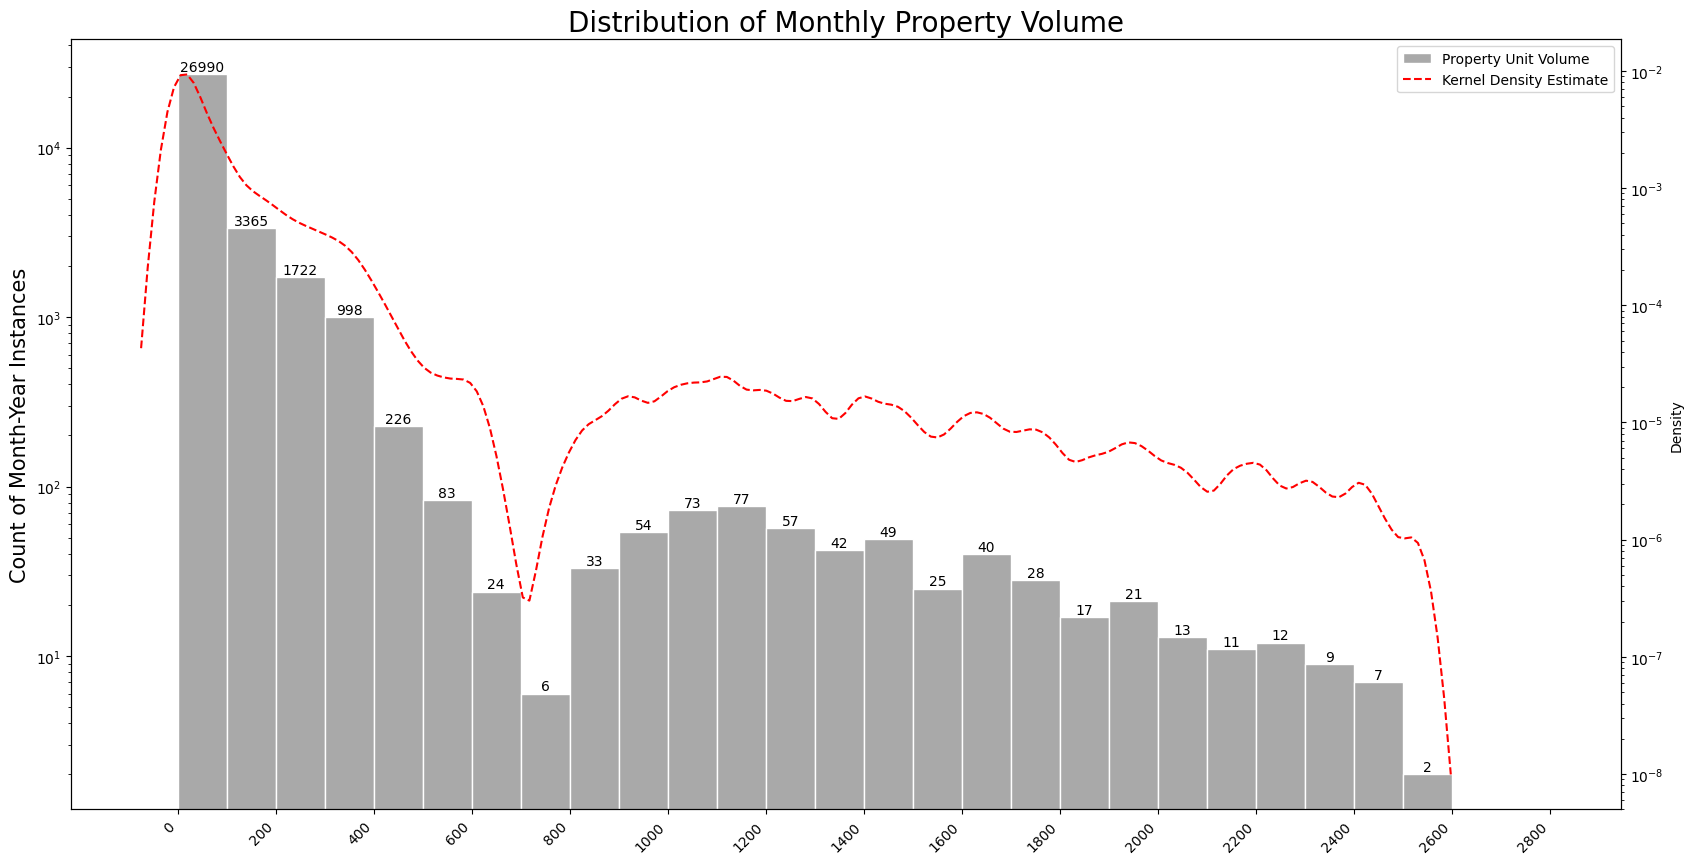

In [9]:
x_ticks = np.arange(0,5000,200)
fig, ax = plt.subplots(figsize=(20,10))
counts, bins, patches = ax.hist(median_sales['volume_units'], bins=28, range=[0,2800], log=True,
                                label='Property Unit Volume', **{'facecolor':'darkgrey','edgecolor':'white'})
ax.set_xticks(x_ticks, x_ticks.astype('int'), rotation=45, ha='right')
ax.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge')
ax.set_ylabel('Count of Month-Year Instances', fontsize=15)
ax2 = ax.twinx()
sns.kdeplot(median_sales['volume_units'], ax=ax2, color="red", linestyle="--", 
            label="Kernel Density Estimate", log_scale=(False, True))
ax2.set_ylabel("Density")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.title(f'Distribution of Monthly Property Volume', fontsize=20)
plt.xlabel('Volume of Units')
plt.show()

Most monthly median sale prices are derived from less than 100 property units of data. Let's ensure that we're only working with data with an appropriate sample size of property units.

In [10]:
median_sales.loc[~(median_sales['volume_units'] >= 75), 'median_sale'] = np.nan
# drop row entries where sales prices have less than the threshold of units
median_sales = median_sales.loc[~(np.isnan(median_sales['median_sale']))]
# we no longer need the context of unit volume
median_sales = median_sales.drop(columns='volume_units')
print(f"# of Neighborhoods = {len(median_sales['neighborhood'].unique())} \n Available Years = {len(median_sales['year'].unique())}")
median_sales

# of Neighborhoods = 78 
 Available Years = 16


,neighborhood,borough,year,month,median_sale
5,Astoria,Queens,2010,01,402000.0
13,Bedford-Stuyvesant,Brooklyn,2010,01,386024.0
25,Brooklyn Heights,Brooklyn,2010,01,795000.0
33,Central Harlem,Manhattan,2010,01,366022.0
36,Chelsea,Manhattan,2010,01,1190000.0
...,...,...,...,...,...
38000,Upper West Side,Manhattan,2025,12,995000.0
38004,Washington Heights,Manhattan,2025,12,395000.0
38006,West Village,Manhattan,2025,12,1450000.0
38010,Williamsburg,Brooklyn,2025,12,1584500.0


In [11]:
# let's adjust the data types for each column
median_sales = median_sales.convert_dtypes()
median_sales['year'] = median_sales['year'].astype('Int64')
median_sales['month'] = median_sales['month'].astype('Int64')
median_sales.dtypes

neighborhood    string[python]
borough         string[python]
year                     Int64
month                    Int64
median_sale            Float64
dtype: object

Let's aggregate, so we can now view data at the annual level.

In [12]:
sales_df = median_sales.groupby(['neighborhood','borough','year'])['median_sale'].mean().reset_index()
print(f"# of Neighborhoods = {len(sales_df['neighborhood'].unique())} \n Available Years = {sales_df['year'].nunique()}")
sales_df

# of Neighborhoods = 78 
 Available Years = 16


,neighborhood,borough,year,median_sale
0,Astoria,Queens,2010,426716.333333
1,Astoria,Queens,2011,440511.25
2,Astoria,Queens,2012,453209.090909
3,Astoria,Queens,2013,494880.625
4,Astoria,Queens,2014,548337.375
...,...,...,...,...
869,Woodside,Queens,2021,574659.8
870,Woodside,Queens,2022,531304.0
871,Woodside,Queens,2023,523470.363636
872,Woodside,Queens,2024,623093.666667


In [13]:
# Here are all of the neighborhoods from the Property Median Sale Price Dataset
sales_df['neighborhood'].unique()

<StringArray>
[            'Astoria',          'Bath Beach',   'Battery Park City',
           'Bay Ridge',             'Bayside',  'Bedford-Stuyvesant',
         'Bensonhurst',        'Bergen Beach',         'Boerum Hill',
        'Borough Park',      'Brighton Beach',    'Brooklyn Heights',
            'Bushwick',            'Canarsie',     'Carroll Gardens',
      'Central Harlem',  'Central Park South',             'Chelsea',
        'Clinton Hill',         'Cobble Hill',        'Coney Island',
       'Crown Heights',               'DUMBO',         'Ditmas Park',
   'Downtown Brooklyn',       'Dyker Heights',       'East Flatbush',
         'East Harlem',       'East New York',        'East Village',
            'Elmhurst',  'Financial District',            'Flatbush',
            'Flatiron',            'Flushing',        'Forest Hills',
         'Fort Greene',            'Glendale',             'Gowanus',
       'Gramercy Park',           'Gravesend',          'Greenpoint',
   'Gr

## Importing Income Data

In [14]:
# importing median HH income and year-over-year changes in HH income data
query = """
    SELECT 
        n.name AS neighborhood,
        yic.borough_name AS borough,
        yic.year AS year,
        yic.yoy_change_pct_all_hhs,
        yic.yoy_change_pct_singles,
        yic.yoy_change_pct_other_kids,
        yic.yoy_change_pct_married_kids,
        mi.all_hhs AS median_all_hhs,
        mi.singles AS median_singles,
        mi.married_kids AS median_married_kids,
        mi.other_kids AS median_other_kids
    FROM nyc_analysis.agg_yoy_income_change yic
    JOIN nyc_analysis.ref_neighborhoods n ON n.name = yic.neighborhood_name
    JOIN nyc_analysis.ref_district_neighborhoods dn ON dn.neighborhood_id = n.neighborhood_id 
    JOIN nyc_analysis.fact_median_income mi ON mi.district_id = dn.district_id
        AND mi.year = yic.year 
    ORDER BY neighborhood, year
    """
income_df = client.query(query).to_dataframe()
print(f"# of Neighborhoods = {len(income_df['neighborhood'].unique())} \n Available Years = {len(income_df['year'].unique())}")
income_df

# of Neighborhoods = 99 
 Available Years = 10


,neighborhood,borough,year,yoy_change_pct_all_hhs,yoy_change_pct_singles,yoy_change_pct_other_kids,yoy_change_pct_married_kids,median_all_hhs,median_singles,median_married_kids,median_other_kids
0,Astoria,Queens,2012,None,None,None,None,51856.000000000,50074.000000000,23305.000000000,323.000000000
1,Astoria,Queens,2013,-1.730000000,5.050000000,-29.410000000,8.930000000,50960.000000000,52602.000000000,25385.000000000,228.000000000
2,Astoria,Queens,2014,10.420000000,2.000000000,24.560000000,7.040000000,56269.000000000,53656.000000000,27173.000000000,284.000000000
3,Astoria,Queens,2015,2.500000000,-2.020000000,-30.630000000,-8.530000000,57678.000000000,52573.000000000,24855.000000000,197.000000000
4,Astoria,Queens,2016,4.730000000,8.220000000,-33.500000000,-8.660000000,60406.000000000,56897.000000000,22702.000000000,131.000000000
...,...,...,...,...,...,...,...,...,...,...,...
987,Woodside,Queens,2017,8.160000000,18.080000000,None,None,67359.000000000,60010.000000000,0E-9,0E-9
988,Woodside,Queens,2018,5.500000000,1.000000000,None,None,71061.000000000,60610.000000000,0E-9,0E-9
989,Woodside,Queens,2019,13.860000000,-8.260000000,None,None,80913.000000000,55606.000000000,0E-9,0E-9
990,Woodside,Queens,2021,-0.250000000,36.740000000,None,None,80708.000000000,76033.000000000,0E-9,0E-9


It looks ZEROS were introduced to the income dataset as well, so let's fix that.

In [15]:
structural_zero_cols = income_df.columns.copy()
# these columns CAN logically contain zeros, so they are omitted
structural_zero_cols = structural_zero_cols.drop(['yoy_change_pct_all_hhs',
                                                  'yoy_change_pct_singles', 
                                                  'yoy_change_pct_other_kids',
                                                  'yoy_change_pct_married_kids'])
income_df[structural_zero_cols] = income_df[structural_zero_cols].replace(0, np.nan)
# let's adjust the data types for each column
income_df = income_df.convert_dtypes()
income_df['yoy_change_pct_all_hhs'] = income_df['yoy_change_pct_all_hhs'].astype('Float64')
income_df['yoy_change_pct_singles'] = income_df['yoy_change_pct_singles'].astype('Float64')
income_df['yoy_change_pct_other_kids'] = income_df['yoy_change_pct_other_kids'].astype('Float64')
income_df['yoy_change_pct_married_kids'] = income_df['yoy_change_pct_married_kids'].astype('Float64')
income_df['median_all_hhs'] = income_df['median_all_hhs'].astype('Float64')
income_df['median_singles'] = income_df['median_singles'].astype('Float64')
income_df['median_other_kids'] = income_df['median_other_kids'].astype('Float64')
income_df['median_married_kids'] = income_df['median_married_kids'].astype('Float64')
income_df.dtypes

neighborhood                   string[python]
borough                        string[python]
year                                    Int64
yoy_change_pct_all_hhs                Float64
yoy_change_pct_singles                Float64
yoy_change_pct_other_kids             Float64
yoy_change_pct_married_kids           Float64
median_all_hhs                        Float64
median_singles                        Float64
median_married_kids                   Float64
median_other_kids                     Float64
dtype: object

In [16]:
# Here are all of the neighborhoods from the Income Dataset
income_df['neighborhood'].unique()

<StringArray>
[                  'Astoria',                'Auburndale',
                'Bath Beach',         'Battery Park City',
                 'Bay Ridge',                   'Bayside',
        'Bedford-Stuyvesant',                 'Bellerose',
               'Bensonhurst',              'Borough Park',
                 'Briarwood',            'Brighton Beach',
          'Brooklyn Heights',               'Brownsville',
                  'Bushwick',           'Cambria Heights',
                  'Canarsie',           'Carroll Gardens',
            'Central Harlem',                   'Chelsea',
                 'Chinatown',              'Coney Island',
                    'Corona',             'Crown Heights',
                'Douglaston',         'Downtown Brooklyn',
             'Dyker Heights',               'East Harlem',
             'East New York',                  'Elmhurst',
        'Financial District',                  'Flatbush',
                  'Flatiron',             

## Merging Datasets

Let's merge these dataframes, so all income, property value, and rent data are in one location

In [17]:
# merging all datasets to create one primary df
gentrification_df = pd.merge(sales_df, pd.merge(income_df, rent_df, how='inner', 
                                                on=['neighborhood','borough','year']),
                            how='inner', on=['neighborhood','borough','year'])
# reconciling duplicate borough+neighborhood+year entries, due to PUMA district names (e.g. Crown Heights North/South)
gentrification_df = gentrification_df.groupby(['borough','neighborhood', 'year']).mean().reset_index()
print(f"{len(gentrification_df['neighborhood'].unique())} Neighborhoods \n{gentrification_df['year'].nunique()} "
      f"Available Years = {gentrification_df['year'].copy().drop_duplicates().sort_values().to_list()}")
print(f"Neighborhoods:\n{gentrification_df['neighborhood'].unique()}")
gentrification_df

30 Neighborhoods 
10 Available Years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022]
Neighborhoods:
<StringArray>
[         'Bay Ridge', 'Bedford-Stuyvesant',   'Brooklyn Heights',
           'Bushwick',      'Crown Heights',  'Downtown Brooklyn',
           'Flatbush',         'Greenpoint',            'Midwood',
         'Park Slope',       'Williamsburg',  'Battery Park City',
     'Central Harlem',            'Chelsea',        'East Harlem',
 'Financial District',           'Flatiron',      'Gramercy Park',
   'Hamilton Heights',    'Lower East Side',            'Midtown',
       'Midtown East',       'Midtown West',    'Upper East Side',
    'Upper West Side', 'Washington Heights',            'Astoria',
       'Forest Hills',   'Long Island City',          'Rego Park']
Length: 30, dtype: string


,borough,neighborhood,year,median_sale,yoy_change_pct_all_hhs,yoy_change_pct_singles,yoy_change_pct_other_kids,yoy_change_pct_married_kids,median_all_hhs,median_singles,median_married_kids,median_other_kids,avg_median_all_apts,avg_median_1bdr_apts,avg_median_3bdr_apts,yoy_change_pct_all_apts,yoy_change_pct_1bdr,yoy_change_pct_3bdr
0,Brooklyn,Bay Ridge,2015,431909.708333,13.55,21.45,<NA>,<NA>,64378.0,51643.0,<NA>,<NA>,1806.916667,<NA>,<NA>,5.81,-100.0,<NA>
1,Brooklyn,Bay Ridge,2016,510541.666667,3.4,-7.35,<NA>,<NA>,66570.0,47849.0,<NA>,<NA>,2037.5,<NA>,<NA>,12.76,<NA>,<NA>
2,Brooklyn,Bay Ridge,2017,546046.583333,3.17,-6.38,<NA>,<NA>,68679.0,44798.0,<NA>,<NA>,1940.833333,550.833333,<NA>,-4.74,<NA>,<NA>
3,Brooklyn,Bay Ridge,2018,706690.791667,5.42,0.42,<NA>,<NA>,72402.0,44985.0,<NA>,<NA>,1956.875,706.125,<NA>,0.83,28.19,<NA>
4,Brooklyn,Bay Ridge,2019,606333.791667,5.76,20.92,<NA>,<NA>,76569.0,54397.0,<NA>,<NA>,1941.583333,990.125,<NA>,-0.78,40.22,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,Queens,Long Island City,2018,893044.958333,2.745,0.57,<NA>,<NA>,69252.5,59361.5,<NA>,<NA>,3036.75,3046.333333,<NA>,2.05,2.11,<NA>
190,Queens,Long Island City,2019,957158.875,6.81,-3.055,<NA>,<NA>,80046.5,61707.0,<NA>,<NA>,3220.583333,3222.708333,<NA>,6.05,5.79,<NA>
191,Queens,Long Island City,2021,1055824.916667,0.32,16.945,<NA>,<NA>,77123.5,70059.0,<NA>,<NA>,3248.708333,3239.583333,<NA>,6.5,6.67,<NA>
192,Queens,Long Island City,2022,1014837.958333,0.285,-1.29,<NA>,<NA>,81167.0,73591.5,<NA>,<NA>,3905.416667,3783.333333,<NA>,20.21,16.78,<NA>


We want to make sure we're analyzing neighborhoods with sufficient data, so we are going to exclude neighborhoods with less than 4 years of data.

In [18]:
neighborhoods = gentrification_df['neighborhood'].unique()
for NBHD in neighborhoods:
    if len(gentrification_df[gentrification_df['neighborhood'] == NBHD]) < 4:
        gentrification_df = gentrification_df[gentrification_df['neighborhood'] != NBHD]

print(f"{len(gentrification_df['neighborhood'].unique())} Neighborhoods \n{gentrification_df['year'].nunique()} "
      f"Available Years: {gentrification_df['year'].copy().drop_duplicates().sort_values().to_list()}")
print(f"Neighborhoods:\n{gentrification_df['neighborhood'].unique()}")

23 Neighborhoods 
10 Available Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022]
Neighborhoods:
<StringArray>
[         'Bay Ridge', 'Bedford-Stuyvesant',           'Bushwick',
      'Crown Heights',  'Downtown Brooklyn',           'Flatbush',
         'Greenpoint',         'Park Slope',       'Williamsburg',
  'Battery Park City',     'Central Harlem',            'Chelsea',
        'East Harlem', 'Financial District',      'Gramercy Park',
   'Hamilton Heights',    'Lower East Side',    'Upper East Side',
    'Upper West Side', 'Washington Heights',            'Astoria',
       'Forest Hills',   'Long Island City']
Length: 23, dtype: string


Let's visualize the rent time series for all of these neighbrhoods

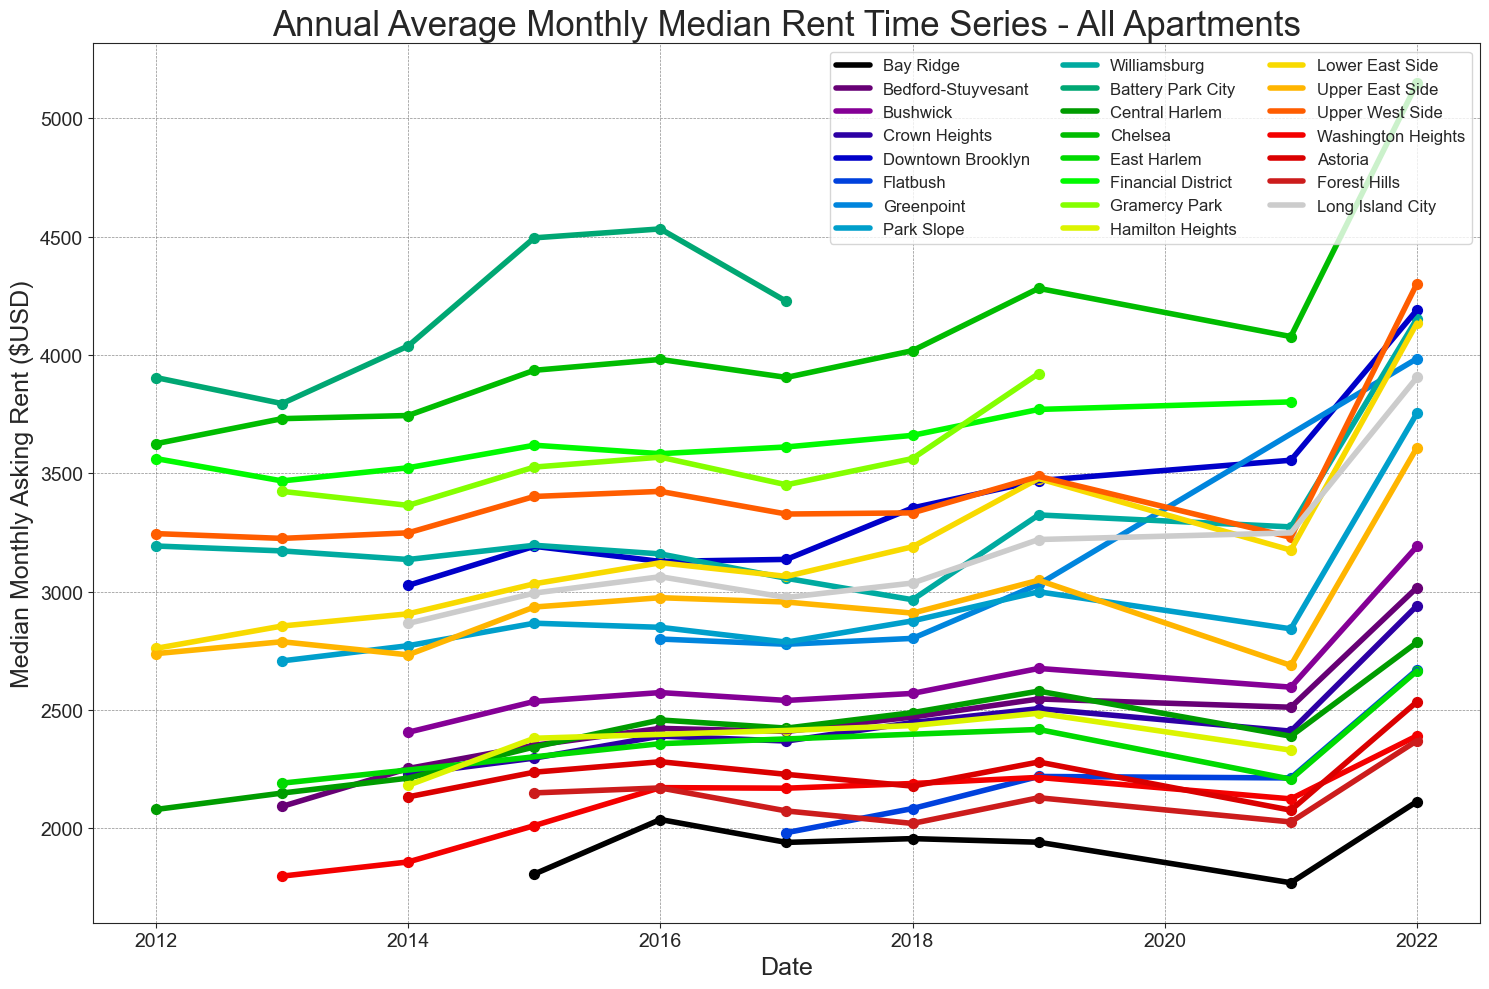

In [19]:
neighborhoods = gentrification_df['neighborhood'].unique()
cmap = mpl.colormaps['nipy_spectral']
colors = cmap(np.linspace(0,1,len(neighborhoods)))
sns.set_style('ticks')

plt.figure(figsize=(15,10))
for i, NBHD in enumerate(neighborhoods):
    neighborhood_df = gentrification_df[gentrification_df['neighborhood'] == NBHD]
    subset_df = neighborhood_df[['year','avg_median_all_apts']]
    plt.plot(subset_df['year'], subset_df['avg_median_all_apts'], label=NBHD, color=colors[i], linewidth=4)
    plt.scatter(subset_df['year'], subset_df['avg_median_all_apts'], color=colors[i], s=50)

plt.legend(loc='best', ncol=3, fontsize=12)
plt.title('Annual Average Monthly Median Rent Time Series - All Apartments', fontsize=25)
plt.xlabel('Date', fontsize=18)
plt.xticks(fontsize=14)
plt.ylabel('Median Monthly Asking Rent ($USD)', fontsize=18)
plt.yticks(fontsize=14)
plt.grid(which='major',axis='both',color='gray',lw=0.5, ls='--', alpha=0.9)
plt.tight_layout() 
plt.show()

# Machine Learning Gentrification Analysis

## Determining Raw Column Preservation

Some of these features may have lots of rows with NaNs, indicating there is simply not enough data for it to meaningfully contribute to the analysis. 

We're going to find those columns/features, and exclude them from analysis.

In [20]:
features = gentrification_df.columns
valid_features = []
for f in features:
    if gentrification_df[f].isna().mean() > 0.33:
        print(f"{f} NaN % = {gentrification_df[f].isna().mean():.02}")
    else:
        valid_features.append(f)

yoy_change_pct_other_kids NaN % = 0.91
yoy_change_pct_married_kids NaN % = 0.91
median_married_kids NaN % = 0.93
median_other_kids NaN % = 0.93
avg_median_3bdr_apts NaN % = 0.57
yoy_change_pct_3bdr NaN % = 0.58


It looks like the columns/features for families with children, and some of the 3+Bdr apartment columns are missing too much data, so we are going to remove them from the clustering analysis.

In [21]:
gentrification_df = gentrification_df[valid_features]

## Filling remaining NaNs with values based on KNN

In [22]:
# first, we will fill in NaN values using K-Nearest Neighbors
imputer = KNNImputer(n_neighbors=3)

# impute missing values
filled_df = pd.DataFrame(
    imputer.fit_transform(gentrification_df.iloc[:,2:]),
    columns=gentrification_df.columns[2:],
    index=gentrification_df.index)

# create complete + filles dataset for analysis
main_df = gentrification_df.iloc[:,:2].join(filled_df)
main_df

,borough,neighborhood,year,median_sale,yoy_change_pct_all_hhs,yoy_change_pct_singles,median_all_hhs,median_singles,avg_median_all_apts,avg_median_1bdr_apts,yoy_change_pct_all_apts,yoy_change_pct_1bdr
0,Brooklyn,Bay Ridge,2015.0,4.319097e+05,13.550,21.450,64378.0,51643.0,1806.916667,767.888889,5.81,-100.000000
1,Brooklyn,Bay Ridge,2016.0,5.105417e+05,3.400,-7.350,66570.0,47849.0,2037.500000,1238.472222,12.76,-15.160000
2,Brooklyn,Bay Ridge,2017.0,5.460466e+05,3.170,-6.380,68679.0,44798.0,1940.833333,550.833333,-4.74,174.033333
3,Brooklyn,Bay Ridge,2018.0,7.066908e+05,5.420,0.420,72402.0,44985.0,1956.875000,706.125000,0.83,28.190000
4,Brooklyn,Bay Ridge,2019.0,6.063338e+05,5.760,20.920,76569.0,54397.0,1941.583333,990.125000,-0.78,40.220000
...,...,...,...,...,...,...,...,...,...,...,...,...
188,Queens,Long Island City,2017.0,9.470654e+05,4.030,9.340,66870.5,60876.5,2975.750000,2983.500000,-2.86,-1.200000
189,Queens,Long Island City,2018.0,8.930450e+05,2.745,0.570,69252.5,59361.5,3036.750000,3046.333333,2.05,2.110000
190,Queens,Long Island City,2019.0,9.571589e+05,6.810,-3.055,80046.5,61707.0,3220.583333,3222.708333,6.05,5.790000
191,Queens,Long Island City,2021.0,1.055825e+06,0.320,16.945,77123.5,70059.0,3248.708333,3239.583333,6.50,6.670000


## Creating + Evaluating Features/Metrics

let's create a categorical feature that indicates whether a neighborhood is in a particular borough

In [23]:
main_df['borough_brooklyn'] = (main_df['borough'] == 'Brooklyn').astype(int)
main_df['borough_queens'] = (main_df['borough'] == 'Queens').astype(int)
main_df['borough_manhattan'] = (main_df['borough'] == 'Manhattan').astype(int)

Here, we are going to create columns of data on rent and income volatility, affordability ratios, rent price acceleration, gentrification intensity, and other variables to develop neighborhood-level statistical information to supplement our machine learning analysis.

In [24]:
# Feature Engineering for Gentrification Detection
df_temp1 = gt.engineer_gentrification_features(main_df) 
df_temp1 = df_temp1.rename(columns={
    'yoy_change_pct_all_apts_<lambda_0>': 'yoy_pct_change_gt_10_all_apts',
    'yoy_change_pct_all_apts_<lambda_1>': 'yoy_pct_change_gt_15_all_apts',
    'yoy_change_pct_1bdr_<lambda_0>': 'yoy_pct_change_gt_10_1bdr',
    'yoy_change_pct_1bdr_<lambda_1>': 'yoy_pct_change_gt_15_1bdr',
    'yoy_change_pct_3bdr_<lambda_0>': 'yoy_pct_change_gt_10_3bdr',
    'yoy_change_pct_3bdr_<lambda_1>': 'yoy_pct_change_gt_15_3bdr'
})
print(df_temp1.columns)
df_temp1

Index(['neighborhood', 'yoy_change_pct_all_apts_mean',
       'yoy_change_pct_all_apts_std', 'yoy_change_pct_all_apts_max',
       'yoy_change_pct_all_apts_min', 'yoy_pct_change_gt_10_all_apts',
       'yoy_pct_change_gt_15_all_apts', 'yoy_change_pct_1bdr_mean',
       'yoy_change_pct_1bdr_std', 'yoy_change_pct_1bdr_max',
       'yoy_change_pct_1bdr_min', 'yoy_pct_change_gt_10_1bdr',
       'yoy_pct_change_gt_15_1bdr', 'yoy_change_pct_all_hhs_mean',
       'yoy_change_pct_all_hhs_std', 'yoy_change_pct_all_hhs_max',
       'yoy_change_pct_all_hhs_min', 'yoy_change_pct_singles_mean',
       'yoy_change_pct_singles_std', 'yoy_change_pct_singles_max',
       'yoy_change_pct_singles_min', 'avg_median_all_apts_mean',
       'avg_median_all_apts_std', 'avg_median_all_apts_max',
       'avg_median_all_apts_min', 'avg_median_1bdr_apts_mean',
       'avg_median_1bdr_apts_std', 'avg_median_1bdr_apts_max',
       'avg_median_1bdr_apts_min', 'median_all_hhs_mean', 'median_all_hhs_std',
       'medi

,neighborhood,yoy_change_pct_all_apts_mean,yoy_change_pct_all_apts_std,yoy_change_pct_all_apts_max,yoy_change_pct_all_apts_min,yoy_pct_change_gt_10_all_apts,yoy_pct_change_gt_15_all_apts,yoy_change_pct_1bdr_mean,yoy_change_pct_1bdr_std,yoy_change_pct_1bdr_max,...,1bdr_total_rent_change,all_total_income_change,singles_total_income_change,all_rent_income_ratio,singles_rent_income_ratio,all_gentrification_intensity,1bdr_gentrification_intensity,all_price_acceleration,1bdr_price_acceleration,total_sale_price_change
0,Astoria,3.282500,8.404716,22.05,-5.29,1,1,58.781250,156.747608,446.230000,...,405.833333,24898.0,20571.0,0.397416,0.380932,0.152564,0.305977,18.767500,387.448750,334745.958333
1,Battery Park City,3.068333,7.152576,11.31,-6.76,1,0,-7.721667,25.872716,24.006667,...,2082.111111,42004.0,31512.0,0.398498,0.316305,0.199078,0.816142,8.241667,31.728333,688927.727273
2,Bay Ridge,3.512857,9.871767,19.38,-8.67,2,1,22.129048,104.712903,174.033333,...,840.750000,16927.0,16731.0,0.323336,0.232538,0.341097,1.443614,15.867143,151.904286,358669.375000
3,Bedford-Stuyvesant,6.355556,6.808254,20.13,-0.52,2,1,28.860000,50.118808,154.110000,...,1864.333333,36445.0,41114.0,0.562834,0.495537,0.320416,1.556649,13.774444,125.250000,546109.458333
4,Bushwick,4.476250,7.727524,22.91,-1.29,1,1,51.069167,85.705856,259.240000,...,2465.375000,50273.0,45106.0,0.545787,0.344774,0.165809,5.839077,18.433750,208.170833,366851.041667
5,Central Harlem,3.967000,5.355521,16.58,-3.87,1,1,24.783000,56.157954,150.910000,...,1358.666667,18091.0,16198.0,0.633419,0.611814,0.133934,0.509300,12.613000,126.127000,333680.625000
6,Chelsea,5.621000,7.887684,26.24,-1.91,1,1,34.233000,79.109733,249.100000,...,2218.416667,33972.0,24971.0,0.477970,0.515435,0.142003,0.527741,20.619000,214.867000,461974.208333
7,Crown Heights,4.228750,7.448928,21.98,-1.64,1,1,58.739167,148.538878,423.080000,...,1801.458333,34499.5,31744.5,0.493728,0.413605,0.164939,2.791263,17.751250,364.340833,458415.300000
8,Downtown Brooklyn,6.078750,6.421814,17.86,-2.00,2,1,-7.606667,43.145275,47.640000,...,2034.166667,46649.0,31717.0,0.394685,0.277217,0.346118,0.654644,11.781250,55.246667,596166.541667
9,East Harlem,5.518000,9.377277,20.72,-5.11,1,1,-21.610000,71.628568,34.660000,...,877.763889,14400.0,9999.0,0.832453,0.741035,0.243276,1.153285,15.202000,56.270000,174250.000000


Creating a dataframe that documents the neighborhood-level frequency of abnormally high Year-over-Year increases in rent price. These percentages are >= 8%, 12%, and 15%.

In [25]:
# Time Series Pattern Analysis
df_temp2 = gt.analyze_temporal_patterns(main_df)
df_temp2

,neighborhood,all_consec_8pct,all_consec_12pct,all_consec_15pct,1bdr_consec_8pct,1bdr_consec_12pct,1bdr_consec_15pct
0,Astoria,1,1,1,1,1,1
1,Battery Park City,1,0,0,1,1,1
2,Bay Ridge,1,1,1,4,4,4
3,Bedford-Stuyvesant,1,1,1,3,1,1
4,Bushwick,1,1,1,4,2,2
5,Central Harlem,1,1,1,2,1,1
6,Chelsea,2,1,1,2,2,2
7,Crown Heights,1,1,1,1,1,1
8,Downtown Brooklyn,2,2,1,1,1,1
9,East Harlem,1,1,1,2,2,2


### Selecting Features/Metrics for Clustering

Before clustering the neighborhoods, we need to determine which features are pertinent for this analysis. If a column has low variance, then it isn't a useful metric for differentiation between neighborhoods. If multiple columns are highly correlated with each other, we want to use only one of those features for unsupervised learning. 

In [26]:
engineered_df = df_temp1.merge(df_temp2, how='inner', on='neighborhood')
features_df, removed = gt.select_clustering_features(
        engineered_df, 
        neighborhood_col='neighborhood',
        variance_threshold=0.01,
        correlation_threshold=0.95)
print(f"These columns were removed from analysis due to:\n"
      f"low variance: {removed['low_variance']}\n"
      f"high correlation: {removed['high_correlation']}\n"
      f"infinite vals: {removed['infinite_values']}")
features_df

These columns were removed from analysis due to:
low variance: []
high correlation: ['yoy_pct_change_gt_10_1bdr', 'avg_median_all_apts_mean', 'median_all_hhs_mean', 'median_all_hhs_max', 'median_singles_mean', 'median_sale_mean', 'median_all_hhs_std', 'median_singles_std', 'yoy_change_pct_all_apts_max', 'yoy_change_pct_1bdr_max', 'median_sale_std', 'yoy_pct_change_gt_15_all_apts', '1bdr_consec_12pct']
infinite vals: []


,neighborhood,yoy_change_pct_all_apts_mean,yoy_change_pct_all_apts_std,yoy_change_pct_all_apts_min,yoy_pct_change_gt_10_all_apts,yoy_change_pct_1bdr_mean,yoy_change_pct_1bdr_std,yoy_change_pct_1bdr_min,yoy_pct_change_gt_15_1bdr,yoy_change_pct_all_hhs_mean,...,all_gentrification_intensity,1bdr_gentrification_intensity,all_price_acceleration,1bdr_price_acceleration,total_sale_price_change,all_consec_8pct,all_consec_12pct,all_consec_15pct,1bdr_consec_8pct,1bdr_consec_15pct
0,Astoria,3.282500,8.404716,-5.29,1,58.781250,156.747608,-4.830000,2,6.223750,...,0.152564,0.305977,18.767500,387.448750,334745.958333,1,1,1,1,1
1,Battery Park City,3.068333,7.152576,-6.76,1,-7.721667,25.872716,-41.490000,1,8.256667,...,0.199078,0.816142,8.241667,31.728333,688927.727273,1,0,0,1,1
2,Bay Ridge,3.512857,9.871767,-8.67,2,22.129048,104.712903,-100.000000,4,5.412857,...,0.341097,1.443614,15.867143,151.904286,358669.375000,1,1,1,4,4
3,Bedford-Stuyvesant,6.355556,6.808254,-0.52,2,28.860000,50.118808,0.270000,3,7.653333,...,0.320416,1.556649,13.774444,125.250000,546109.458333,1,1,1,3,1
4,Bushwick,4.476250,7.727524,-1.29,1,51.069167,85.705856,1.343333,5,10.176250,...,0.165809,5.839077,18.433750,208.170833,366851.041667,1,1,1,4,2
5,Central Harlem,3.967000,5.355521,-3.87,1,24.783000,56.157954,-20.750000,2,3.680667,...,0.133934,0.509300,12.613000,126.127000,333680.625000,1,1,1,2,1
6,Chelsea,5.621000,7.887684,-1.91,1,34.233000,79.109733,-18.560000,3,3.768000,...,0.142003,0.527741,20.619000,214.867000,461974.208333,2,1,1,2,2
7,Crown Heights,4.228750,7.448928,-1.64,1,58.739167,148.538878,-22.786667,3,4.088125,...,0.164939,2.791263,17.751250,364.340833,458415.300000,1,1,1,1,1
8,Downtown Brooklyn,6.078750,6.421814,-2.00,2,-7.606667,43.145275,-100.000000,2,7.176250,...,0.346118,0.654644,11.781250,55.246667,596166.541667,2,2,1,1,1
9,East Harlem,5.518000,9.377277,-5.11,1,-21.610000,71.628568,-100.000000,3,2.906000,...,0.243276,1.153285,15.202000,56.270000,174250.000000,1,1,1,2,2


Let's determine which features are most important (highest variance + least correlated). This will be useful when interpreting our results.

In [27]:
important_df = gt.get_feature_importance_for_correlation(engineered_df)
important_df.head(15)

,feature,variance,mean_abs_correlation,importance_score
13,yoy_change_pct_all_hhs_std,1.045455,0.180994,0.856234
9,yoy_change_pct_1bdr_min,1.045455,0.182872,0.854270
18,yoy_change_pct_singles_max,1.045455,0.185364,0.851665
3,yoy_change_pct_all_apts_min,1.045455,0.194246,0.842379
14,yoy_change_pct_all_hhs_max,1.045455,0.195253,0.841326
1,yoy_change_pct_all_apts_std,1.045455,0.199653,0.836727
42,borough_queens_first,1.045455,0.204207,0.831965
49,singles_rent_income_ratio,1.045455,0.214730,0.820964
4,yoy_pct_change_gt_10_all_apts,1.045455,0.216108,0.819523
60,1bdr_consec_15pct,1.045455,0.217290,0.818287


## Using Unsupervised Machine Learning to Cluster NYC Neighborhoods

We are going to use Scikit-Learn to conduct this analysis. You can find the detailed implementation of its modules and functions in utils/gentrification_tools.py

In [37]:
# Clustering to identify stages of gentrification
cluster_features = features_df.columns[1:].to_list()

results_df, kmeans, fitted_scalar, cluster_df = gt.cluster_gentrification_groups(
    features_df,
    cluster_features, 
    k_range=range(4,5))

# viewing clustering results
results_df[['neighborhood','gentrification_group']].sort_values('gentrification_group')

Optimal number of clusters: 4


,neighborhood,gentrification_group
0,Astoria,0
2,Bay Ridge,0
12,Forest Hills,0
1,Battery Park City,1
10,Financial District,1
13,Gramercy Park,1
6,Chelsea,1
19,Upper East Side,1
18,Park Slope,1
20,Upper West Side,1


### Let's look at the numbers

Let's look into the data of each gentrification group to evaluate how they differ:

In [30]:
group_df = features_df.groupby('gentrification_group').agg(
    {x: 'mean' for x in cluster_features}).round(2)
group_df

,yoy_change_pct_all_apts_mean,yoy_change_pct_all_apts_std,yoy_change_pct_all_apts_min,yoy_pct_change_gt_10_all_apts,yoy_change_pct_1bdr_mean,yoy_change_pct_1bdr_std,yoy_change_pct_1bdr_min,yoy_pct_change_gt_15_1bdr,yoy_change_pct_all_hhs_mean,yoy_change_pct_all_hhs_std,...,1bdr_gentrification_intensity,all_price_acceleration,1bdr_price_acceleration,total_sale_price_change,all_consec_8pct,all_consec_12pct,all_consec_15pct,1bdr_consec_8pct,1bdr_consec_15pct,gentrification_group
gentrification_group,,,,,,,,,,,,,,,,,,,,,
0,3.26,8.49,-6.15,1.33,23.95,100.52,-68.28,2.00,5.83,6.32,...,0.58,16.20,184.84,260710.71,1.00,1.00,1.00,1.67,1.67,0.0
1,3.70,7.96,-3.97,1.00,2.52,32.63,-42.81,1.57,6.24,10.72,...,0.85,18.83,62.63,527481.45,1.14,0.57,0.57,1.14,1.14,1.0
2,5.90,8.33,-1.52,1.57,36.79,91.96,-36.12,3.00,7.26,7.96,...,3.11,16.98,200.84,426836.46,1.29,1.14,1.00,2.00,1.43,2.0
3,4.33,6.67,-3.27,0.83,19.77,56.91,-41.19,3.50,3.74,11.04,...,1.08,13.89,109.56,336973.64,1.00,0.83,0.67,2.67,2.50,3.0


In [47]:
for group in results_df['gentrification_group'].unique():
    print(f'Stats for Group {group}')
    print(f'Neighborhoods: {results_df[results_df['gentrification_group'] == group]['neighborhood'].unique()}')
    print(f'Mean Values: {results_df[results_df['gentrification_group'] == group].iloc[:,1:].mean()}')

Stats for Group 0
Neighborhoods: <StringArray>
['Astoria', 'Bay Ridge', 'Forest Hills']
Length: 3, dtype: string
Mean Values: yoy_change_pct_all_apts_mean          3.256071
yoy_change_pct_all_apts_std           8.489415
yoy_change_pct_all_apts_min          -6.146667
yoy_pct_change_gt_10_all_apts         1.333333
yoy_change_pct_1bdr_mean             23.952004
yoy_change_pct_1bdr_std             100.521267
yoy_change_pct_1bdr_min             -68.276667
yoy_pct_change_gt_15_1bdr             2.000000
yoy_change_pct_all_hhs_mean           5.834583
yoy_change_pct_all_hhs_std            6.315248
yoy_change_pct_all_hhs_max           15.560000
yoy_change_pct_all_hhs_min           -3.823333
yoy_change_pct_singles_mean           5.149464
yoy_change_pct_singles_std           10.455862
yoy_change_pct_singles_max           19.493333
yoy_change_pct_singles_min           -6.480000
avg_median_all_apts_std             125.570658
avg_median_all_apts_max            2339.736111
avg_median_all_apts_min     

### Let's assign gentrification phases to each cluster group

In [55]:
def score_gentrification_phases(df, cluster_col='gentrification_group'):
    """
    Description:
        Score gentrification phases for clusters based on cluster mean feature values.
        
        Uses percentile-based scoring (0-1 scale) with weighted feature combinations
        that reflect expected gentrification phase characteristics.
    
    Input:
        df: DataFrame with cluster assignments and features
        cluster_col: name of cluster assignment column
    
    Output:
        DataFrame with phase scores for each cluster, including:
        - cluster: cluster ID
        - Seed_score, Expanding_score, Intensive_score, Mature_score
        - best_phase: phase with highest score
        - best_phase_score: score of best phase
        - confidence: difference between 1st and 2nd best scores
    """
    
    # Define phase scoring logic
    # Format: {feature_name: {'direction': 'high'/'low'/'mid', 'weight': float}}
    
    phase_definitions = {
        'Seed': {
            # Low absolute values, low volatility, low growth
            'avg_median_1bdr_apts_mean': {'direction': 'low', 'weight': 0.25},
            'median_all_hhs_min': {'direction': 'low', 'weight': 0.15},
            'median_sale_max': {'direction': 'low', 'weight': 0.15},
            'yoy_change_pct_all_apts_mean': {'direction': 'low', 'weight': 0.15},
            'all_gentrification_intensity': {'direction': 'low', 'weight': 0.15},
            'yoy_change_pct_all_apts_std': {'direction': 'low', 'weight': 0.10},
            'all_consec_12pct': {'direction': 'low', 'weight': 0.05}
        },
        'Expanding': {
            # Rising pressure, moderate rents, high rent burden, building momentum
            'all_rent_income_ratio': {'direction': 'high', 'weight': 0.25},
            'singles_rent_income_ratio': {'direction': 'high', 'weight': 0.20},
            'yoy_change_pct_all_apts_mean': {'direction': 'high', 'weight': 0.15},
            'all_price_acceleration': {'direction': 'high', 'weight': 0.15},
            'yoy_change_pct_all_apts_std': {'direction': 'high', 'weight': 0.10},
            'all_consec_8pct': {'direction': 'high', 'weight': 0.10},
            'avg_median_1bdr_apts_mean': {'direction': 'mid', 'weight': 0.05}
        },
        'Intensive': {
            # Highest growth rates, highest intensity, peak volatility
            '1bdr_gentrification_intensity': {'direction': 'high', 'weight': 0.25},
            'all_gentrification_intensity': {'direction': 'high', 'weight': 0.15},
            'yoy_change_pct_1bdr_mean': {'direction': 'high', 'weight': 0.20},
            '1bdr_consec_15pct': {'direction': 'high', 'weight': 0.15},
            'all_consec_12pct': {'direction': 'high', 'weight': 0.10},
            'yoy_change_pct_1bdr_std': {'direction': 'high', 'weight': 0.10},
            'all_total_rent_change': {'direction': 'high', 'weight': 0.05}
        },
        'Mature': {
            # Highest absolute values, low volatility, stabilized growth
            'avg_median_1bdr_apts_mean': {'direction': 'high', 'weight': 0.25},
            'median_all_hhs_min': {'direction': 'high', 'weight': 0.20},
            'median_sale_max': {'direction': 'high', 'weight': 0.20},
            'yoy_change_pct_all_apts_mean': {'direction': 'low', 'weight': 0.15},
            'all_gentrification_intensity': {'direction': 'low', 'weight': 0.10},
            'yoy_change_pct_all_apts_std': {'direction': 'low', 'weight': 0.05},
            'all_consec_12pct': {'direction': 'low', 'weight': 0.05}
        }
    }
    
    # Get all unique features needed
    all_features = set()
    for phase_features in phase_definitions.values():
        all_features.update(phase_features.keys())
    all_features = list(all_features)
    
    # Calculate cluster means
    cluster_means = df.groupby(cluster_col)[all_features].mean()
    
    # Normalize cluster means to 0-1 scale
    normalized_means = cluster_means.copy()
    for feature in all_features:
        if feature in normalized_means.columns:
            values = cluster_means[feature].values.reshape(-1, 1)
            scaler = MinMaxScaler()
            normalized_means[feature] = scaler.fit_transform(values).flatten()
    
    # Calculate scores for each cluster
    results = []
    for cluster_id in cluster_means.index:
        cluster_scores = {'cluster': cluster_id}
        
        for phase_name, phase_features in phase_definitions.items():
            score = 0.0
            total_weight = 0.0
            
            for feature, config in phase_features.items():
                if feature not in normalized_means.columns:
                    continue
                
                norm_value = normalized_means.loc[cluster_id, feature]
                weight = config['weight']
                direction = config['direction']
                
                # Calculate contribution based on direction
                if direction == 'high':
                    contribution = norm_value * weight
                elif direction == 'low':
                    contribution = (1 - norm_value) * weight
                elif direction == 'mid':
                    contribution = (1 - abs(norm_value - 0.5) * 2) * weight
                
                score += contribution
                total_weight += weight
            
            # Normalize by total weight
            cluster_scores[f'{phase_name}_score'] = score / total_weight if total_weight > 0 else 0.0
        
        results.append(cluster_scores)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Determine best phase assignments using ranking algorithm
    score_cols = [col for col in results_df.columns if col.endswith('_score')]
    phase_names = [col.replace('_score', '') for col in score_cols]
    
    # Use ranking algorithm to ensure unique phase assignments
    assignments = _assign_unique_phases(results_df, score_cols, phase_names)
    
    results_df['best_phase'] = [assignments[cluster_id] for cluster_id in results_df['cluster']]
    results_df['best_phase_score'] = [results_df.loc[results_df['cluster'] == cluster_id, 
                                                      f"{assignments[cluster_id]}_score"].values[0]
                                       for cluster_id in results_df['cluster']]
    
    # Calculate confidence (gap between assigned phase and next best)
    confidence_scores = []
    for idx, row in results_df.iterrows():
        cluster_scores = row[score_cols].values
        assigned_score = row['best_phase_score']
        other_scores = cluster_scores[cluster_scores != assigned_score]
        confidence = assigned_score - (other_scores.max() if len(other_scores) > 0 else 0)
        confidence_scores.append(confidence)
    
    results_df['confidence'] = confidence_scores
    
    return results_df

def _assign_unique_phases(results_df, score_cols, phase_names):
    """
    Description:
        Assign unique phases to clusters using a priority-based algorithm.
        
        Algorithm:
        1. For each phase, identify which cluster scores highest on it
        2. If multiple clusters want the same phase, assign to the one with:
        - Highest score on that phase
        - OR if tied, the one with worst alternative options
        3. Reassign "losers" to their next-best available phase
        
    Input:
        results_df: DataFrame with cluster scores
        score_cols: list of score column names
        phase_names: list of phase names
    
    Output:
        dict: {cluster_id: assigned_phase}
    """
    n_clusters = len(results_df)
    n_phases = len(phase_names)
    
    if n_clusters != n_phases:
        # If unequal numbers, fall back to greedy assignment
        return {row['cluster']: row[score_cols].idxmax().replace('_score', '') 
                for _, row in results_df.iterrows()}
    
    # Create score matrix: clusters x phases
    score_matrix = results_df[score_cols].values
    cluster_ids = results_df['cluster'].values
    
    # Track assignments
    assigned_clusters = set()
    assigned_phases = set()
    assignments = {}
    
    # Iterative assignment: assign highest-confidence matches first
    while len(assigned_clusters) < n_clusters:
        best_match = None
        best_score = -1
        best_margin = -1
        
        # Find the best unassigned cluster-phase pair
        for i, cluster_id in enumerate(cluster_ids):
            if cluster_id in assigned_clusters:
                continue
            
            for j, phase in enumerate(phase_names):
                if phase in assigned_phases:
                    continue
                
                score = score_matrix[i, j]
                
                # Calculate margin: how much better is this phase vs next best available?
                available_scores = [score_matrix[i, k] for k, p in enumerate(phase_names) 
                                   if p not in assigned_phases]
                available_scores.sort(reverse=True)
                margin = available_scores[0] - (available_scores[1] if len(available_scores) > 1 else 0)
                
                # Prefer assignments with:
                # 1. High absolute score
                # 2. High margin (strong preference, few good alternatives)
                combined_score = score * 0.7 + margin * 0.3
                
                if combined_score > best_score:
                    best_score = combined_score
                    best_match = (cluster_id, phase, score)
                    best_margin = margin
        
        # Make the assignment
        if best_match:
            cluster_id, phase, score = best_match
            assignments[cluster_id] = phase
            assigned_clusters.add(cluster_id)
            assigned_phases.add(phase)
    
    return assignments


In [56]:
score_df = score_gentrification_phases(results_df)
score_df

,cluster,Seed_score,Expanding_score,Intensive_score,Mature_score,best_phase,best_phase_score,confidence
0,0,0.717171,0.170116,0.442559,0.287111,Seed,0.717171,0.274612
1,1,0.343801,0.402488,0.079999,0.932658,Mature,0.932658,0.530170
2,2,0.360147,0.638290,0.868975,0.243891,Intensive,0.868975,0.230685
3,3,0.818457,0.537167,0.413030,0.374210,Expanding,0.537167,-0.281290


# Visualizing Clustering Results!

In [58]:
def prepare_data(df, features, cluster_col='gentrification_group', neighborhood_col='neighborhood'):
    """
    Prepare data for visualization
    
    Input:
        df: DataFrame with features and cluster assignments
        features: list of feature column names
        cluster_col: name of cluster assignment column
        neighborhood_col: name of neighborhood column
    
    Output:
        X: feature matrix
        y: cluster labels
        neighborhoods: neighborhood names
        X_scaled: standardized features
    """
    neighborhoods = df[neighborhood_col].values
    y = df[cluster_col].values
    X = df[features].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X, y, neighborhoods, X_scaled


def plot_pca_2d(X_scaled, y, neighborhoods, title="PCA: Gentrification Clusters", 
                save_path=None):
    """
    Create 2D PCA plot with cluster labels and neighborhood annotations
    """
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot each cluster
    for cluster in np.unique(y):
        mask = y == cluster
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                  c=PHASE_COLORS[cluster], 
                  label=PHASE_LABELS[cluster],
                  s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add neighborhood labels
    for i, neighborhood in enumerate(neighborhoods):
        ax.annotate(neighborhood, (X_pca[i, 0], X_pca[i, 1]),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, alpha=0.8)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(title='Gentrification Phase', fontsize=10, title_fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    
    return pca


def plot_pca_3d(X_scaled, y, neighborhoods, title="3D PCA: Gentrification Clusters",
                save_path=None):
    """
    Create 3D PCA plot for interactive exploration
    """
    from mpl_toolkits.mplot3d import Axes3D
    
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)
    
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot each cluster
    for cluster in np.unique(y):
        mask = y == cluster
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                  c=PHASE_COLORS[cluster], 
                  label=PHASE_LABELS[cluster],
                  s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add neighborhood labels
    for i, neighborhood in enumerate(neighborhoods):
        ax.text(X_pca[i, 0], X_pca[i, 1], X_pca[i, 2], neighborhood,
               fontsize=7, alpha=0.7)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(title='Gentrification Phase', fontsize=10, title_fontsize=11)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def plot_feature_importance_bar(df, features, cluster_col='gentrification_group',
                                 top_n=20, title="Top Features Driving Cluster Separation",
                                 save_path=None):
    """
    Bar chart showing which features most differentiate clusters
    Uses F-statistic (ANOVA) as importance measure
    """
    from sklearn.feature_selection import f_classif
    
    X = df[features].values
    y = df[cluster_col].values
    
    # Calculate F-statistics
    f_stats, _ = f_classif(X, y)
    
    # Create DataFrame for plotting
    importance_df = pd.DataFrame({
        'Feature': features,
        'F_Statistic': f_stats
    }).sort_values('F_Statistic', ascending=False).head(top_n)
    
    # Clean feature names for display
    importance_df['Feature_Clean'] = importance_df['Feature'].str.replace('_', ' ').str.title()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    bars = ax.barh(range(len(importance_df)), importance_df['F_Statistic'].values,
                   color='steelblue', edgecolor='black', linewidth=0.8)
    
    # Color code by feature type
    for i, (idx, row) in enumerate(importance_df.iterrows()):
        if 'yoy' in row['Feature']:
            bars[i].set_color('#FF6B6B')  # Red for YoY changes
        elif 'consec' in row['Feature']:
            bars[i].set_color('#4ECDC4')  # Teal for consecutive
        elif 'intensity' in row['Feature']:
            bars[i].set_color('#95E1D3')  # Light teal for intensity
        elif 'borough' in row['Feature']:
            bars[i].set_color('#FFA07A')  # Light salmon for borough
        elif 'ratio' in row['Feature']:
            bars[i].set_color('#DDA15E')  # Tan for ratios
    
    ax.set_yticks(range(len(importance_df)))
    ax.set_yticklabels(importance_df['Feature'].values, fontsize=9)
    ax.set_xlabel('F-Statistic (Higher = More Discriminative)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    
    return importance_df


def plot_cluster_heatmap(df, features, cluster_col='gentrification_group',
                         top_n=20, title="Cluster Centroids Heatmap",
                         save_path=None):
    """
    Heatmap showing standardized feature values for each cluster centroid
    """
    X = df[features].values
    y = df[cluster_col].values
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Calculate cluster centroids
    centroids = []
    for cluster in sorted(np.unique(y)):
        mask = y == cluster
        centroids.append(X_scaled[mask].mean(axis=0))
    
    centroids = np.array(centroids)
    
    # Select top features by variance across clusters
    feature_variance = centroids.var(axis=0)
    top_indices = np.argsort(feature_variance)[-top_n:][::-1]
    
    # Create DataFrame for heatmap
    heatmap_data = pd.DataFrame(
        centroids[:, top_indices].T,
        columns=[PHASE_LABELS[i] for i in sorted(np.unique(y))],
        index=[features[i] for i in top_indices]
    )
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 12))
    
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
                center=0, cbar_kws={'label': 'Standardized Value'},
                linewidths=0.5, linecolor='gray', ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Gentrification Phase', fontsize=12)
    ax.set_ylabel('Features', fontsize=12)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    
    return heatmap_data


def plot_key_features_boxplot(df, features_to_plot, cluster_col='gentrification_group',
                               title="Key Features by Gentrification Phase",
                               save_path=None):
    """
    Create boxplots for selected key features across clusters
    """
    n_features = len(features_to_plot)
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, feature in enumerate(features_to_plot):
        ax = axes[idx]
        
        # Prepare data
        plot_data = []
        labels = []
        colors = []
        
        for cluster in sorted(df[cluster_col].unique()):
            cluster_data = df[df[cluster_col] == cluster][feature].values
            plot_data.append(cluster_data)
            labels.append(PHASE_LABELS[cluster])
            colors.append(PHASE_COLORS[cluster])
        
        # Create boxplot
        bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
                        showmeans=True, meanline=True,
                        boxprops=dict(linewidth=1.5),
                        whiskerprops=dict(linewidth=1.5),
                        capprops=dict(linewidth=1.5),
                        medianprops=dict(color='red', linewidth=2),
                        meanprops=dict(color='blue', linewidth=2, linestyle='--'))
        
        # Color boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        # Clean feature name
        clean_name = feature.replace('_', ' ').title()
        ax.set_title(clean_name, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # Remove extra subplots
    for idx in range(n_features, len(axes)):
        fig.delaxes(axes[idx])
    
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def plot_scatter_matrix(df, features_to_plot, cluster_col='gentrification_group',
                        title="Pairwise Feature Relationships",
                        save_path=None):
    """
    Scatter plot matrix for key features
    """
    plot_df = df[features_to_plot + [cluster_col]].copy()
    plot_df['Phase'] = plot_df[cluster_col].map(PHASE_LABELS)
    
    # Create custom color palette
    palette = {PHASE_LABELS[k]: v for k, v in PHASE_COLORS.items()}
    
    g = sns.pairplot(plot_df, hue='Phase', palette=palette,
                     vars=features_to_plot, 
                     diag_kind='kde', plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'black'},
                     corner=True)
    
    g.fig.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def plot_dendrogram_analysis(X_scaled, y, neighborhoods, 
                              title="Hierarchical Clustering Dendrogram",
                              save_path=None):
    """
    Show hierarchical clustering to validate cluster assignments
    """
    # Perform hierarchical clustering
    linkage_matrix = linkage(X_scaled, method='ward')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Color code by assigned cluster
    def get_color(idx):
        return PHASE_COLORS[y[idx]]
    
    dendrogram(linkage_matrix, 
               labels=neighborhoods,
               leaf_font_size=9,
               ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Neighborhood', fontsize=12)
    ax.set_ylabel('Distance (Ward Linkage)', fontsize=12)
    
    # Add legend showing cluster colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=PHASE_COLORS[k], label=PHASE_LABELS[k]) 
                      for k in sorted(PHASE_COLORS.keys())]
    ax.legend(handles=legend_elements, title='K-Means Cluster', 
             loc='upper right', fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def plot_radar_chart(df, features_to_plot, cluster_col='gentrification_group',
                     title="Cluster Profiles - Radar Chart",
                     save_path=None):
    """
    Radar chart showing cluster profiles across key dimensions
    """
    from math import pi
    
    # Calculate cluster means and standardize
    cluster_means = df.groupby(cluster_col)[features_to_plot].mean()
    
    # Standardize to 0-1 scale for each feature
    cluster_means_scaled = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
    
    # Number of variables
    categories = [f.replace('_', ' ').title()[:20] for f in features_to_plot]
    N = len(categories)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    # Plot each cluster
    for cluster in sorted(cluster_means_scaled.index):
        values = cluster_means_scaled.loc[cluster].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, 
               label=PHASE_LABELS[cluster], color=PHASE_COLORS[cluster])
        ax.fill(angles, values, alpha=0.15, color=PHASE_COLORS[cluster])
    
    # Fix axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=8)
    ax.grid(True)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


In [59]:
# Set style for publication-quality plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Define phase labels and colors
PHASE_LABELS = {
    0: 'Seed',
    1: 'Mature', 
    2: 'Intensive',
    3: 'Expanding'
}

PHASE_COLORS = {
    0: '#90EE90',  # Light green - Seed
    1: '#4169E1',  # Royal blue - Mature
    2: '#FF6347',  # Tomato red - Intensive
    3: '#FFD700'   # Gold - Expanding
}

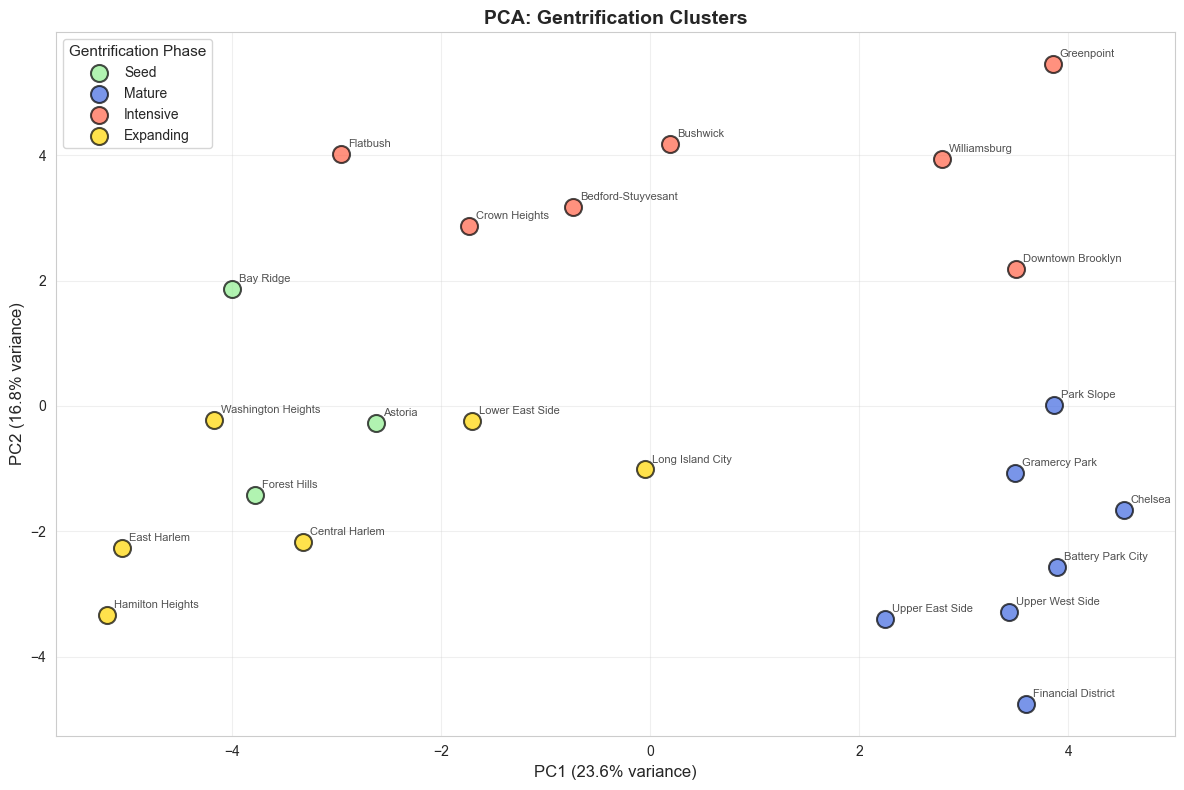

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [68]:
x, y, neighborhoods, x_scaled = prepare_data(results_df, 
                                             features=results_df.columns[1:-1].to_list())
plot_pca_2d(x_scaled, y, neighborhoods)

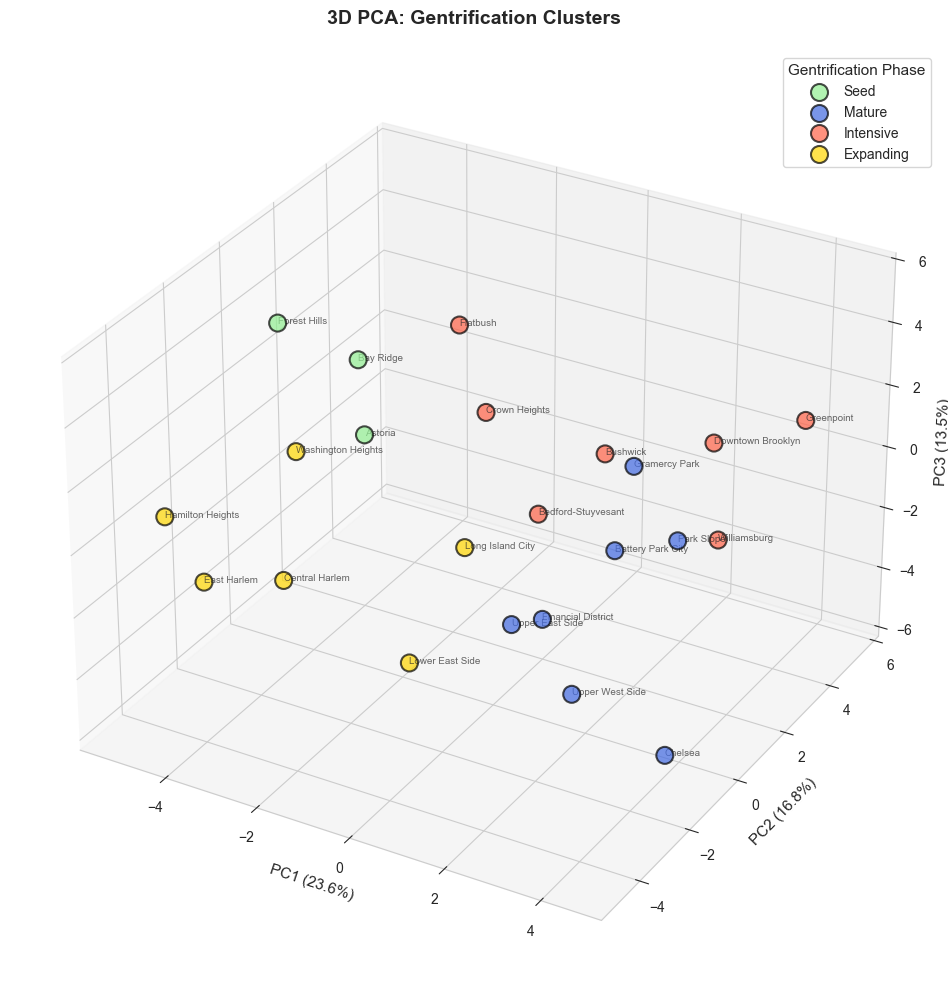

In [69]:
plot_pca_3d(x_scaled, y, neighborhoods)

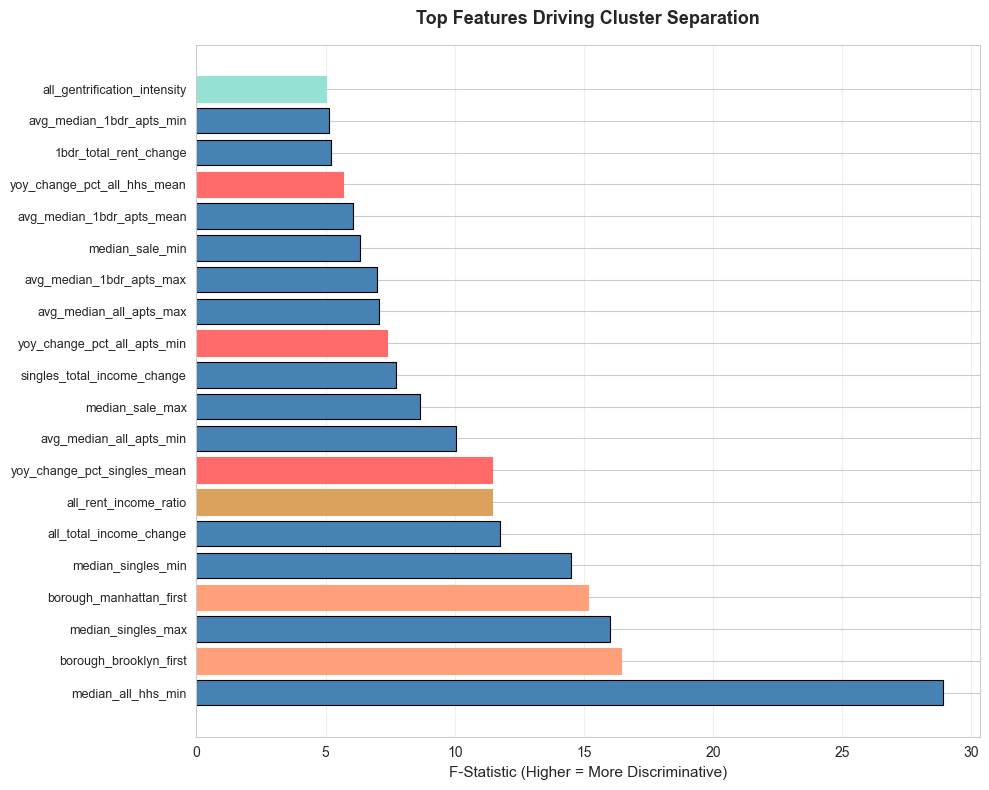

,Feature,F_Statistic,Feature_Clean
23,median_all_hhs_min,28.889760,Median All Hhs Min
28,borough_brooklyn_first,16.435688,Borough Brooklyn First
24,median_singles_max,15.991960,Median Singles Max
29,borough_manhattan_first,15.168198,Borough Manhattan First
25,median_singles_min,14.497178,Median Singles Min
34,all_total_income_change,11.768680,All Total Income Change
36,all_rent_income_ratio,11.456594,All Rent Income Ratio
12,yoy_change_pct_singles_mean,11.452049,Yoy Change Pct Singles Mean
18,avg_median_all_apts_min,10.054942,Avg Median All Apts Min
26,median_sale_max,8.649903,Median Sale Max


In [70]:
plot_feature_importance_bar(results_df, 
                            features=results_df.columns[1:-1].to_list())

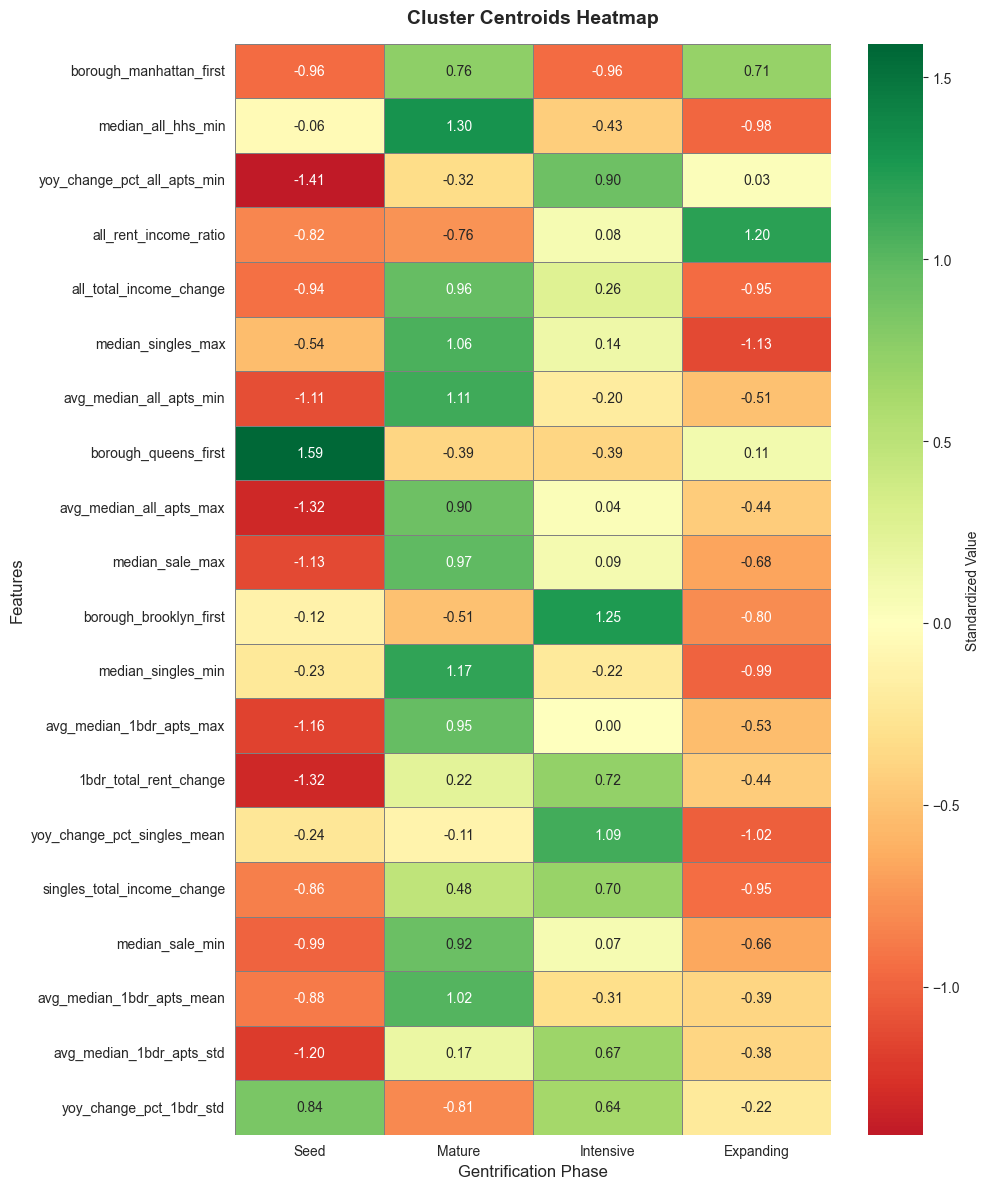

,Seed,Mature,Intensive,Expanding
borough_manhattan_first,-0.957427,0.758481,-0.957427,0.710817
median_all_hhs_min,-0.059679,1.296739,-0.428659,-0.982921
yoy_change_pct_all_apts_min,-1.407380,-0.323598,0.902962,0.027764
all_rent_income_ratio,-0.824889,-0.760230,0.083003,1.202542
all_total_income_change,-0.937215,0.956194,0.261550,-0.952094
median_singles_max,-0.536910,1.057617,0.139928,-1.128680
avg_median_all_apts_min,-1.111569,1.107689,-0.196100,-0.507735
borough_queens_first,1.592226,-0.387298,-0.387298,0.107583
avg_median_all_apts_max,-1.324119,0.902953,0.039485,-0.437451
median_sale_max,-1.132111,0.972794,0.092552,-0.676848


In [72]:
plot_cluster_heatmap(results_df, features=results_df.columns[1:-1].to_list())

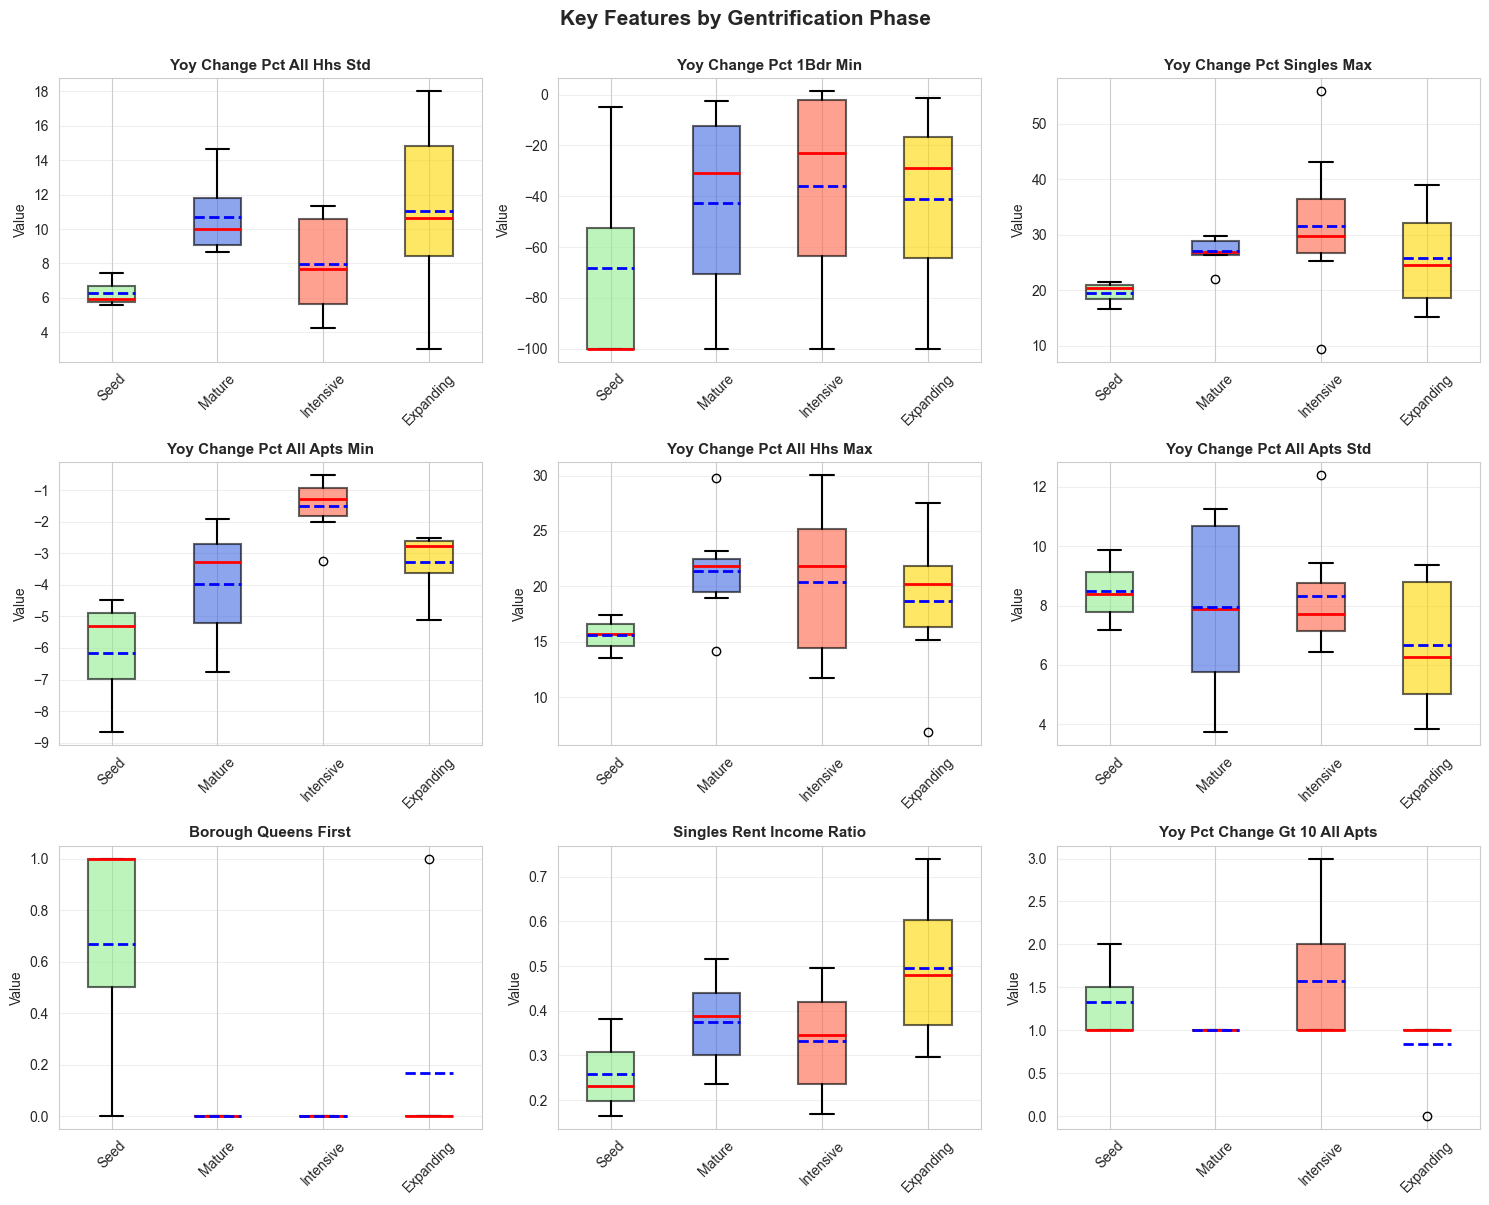

In [77]:
plot_key_features_boxplot(results_df, important_df['feature'].iloc[:9].to_list())

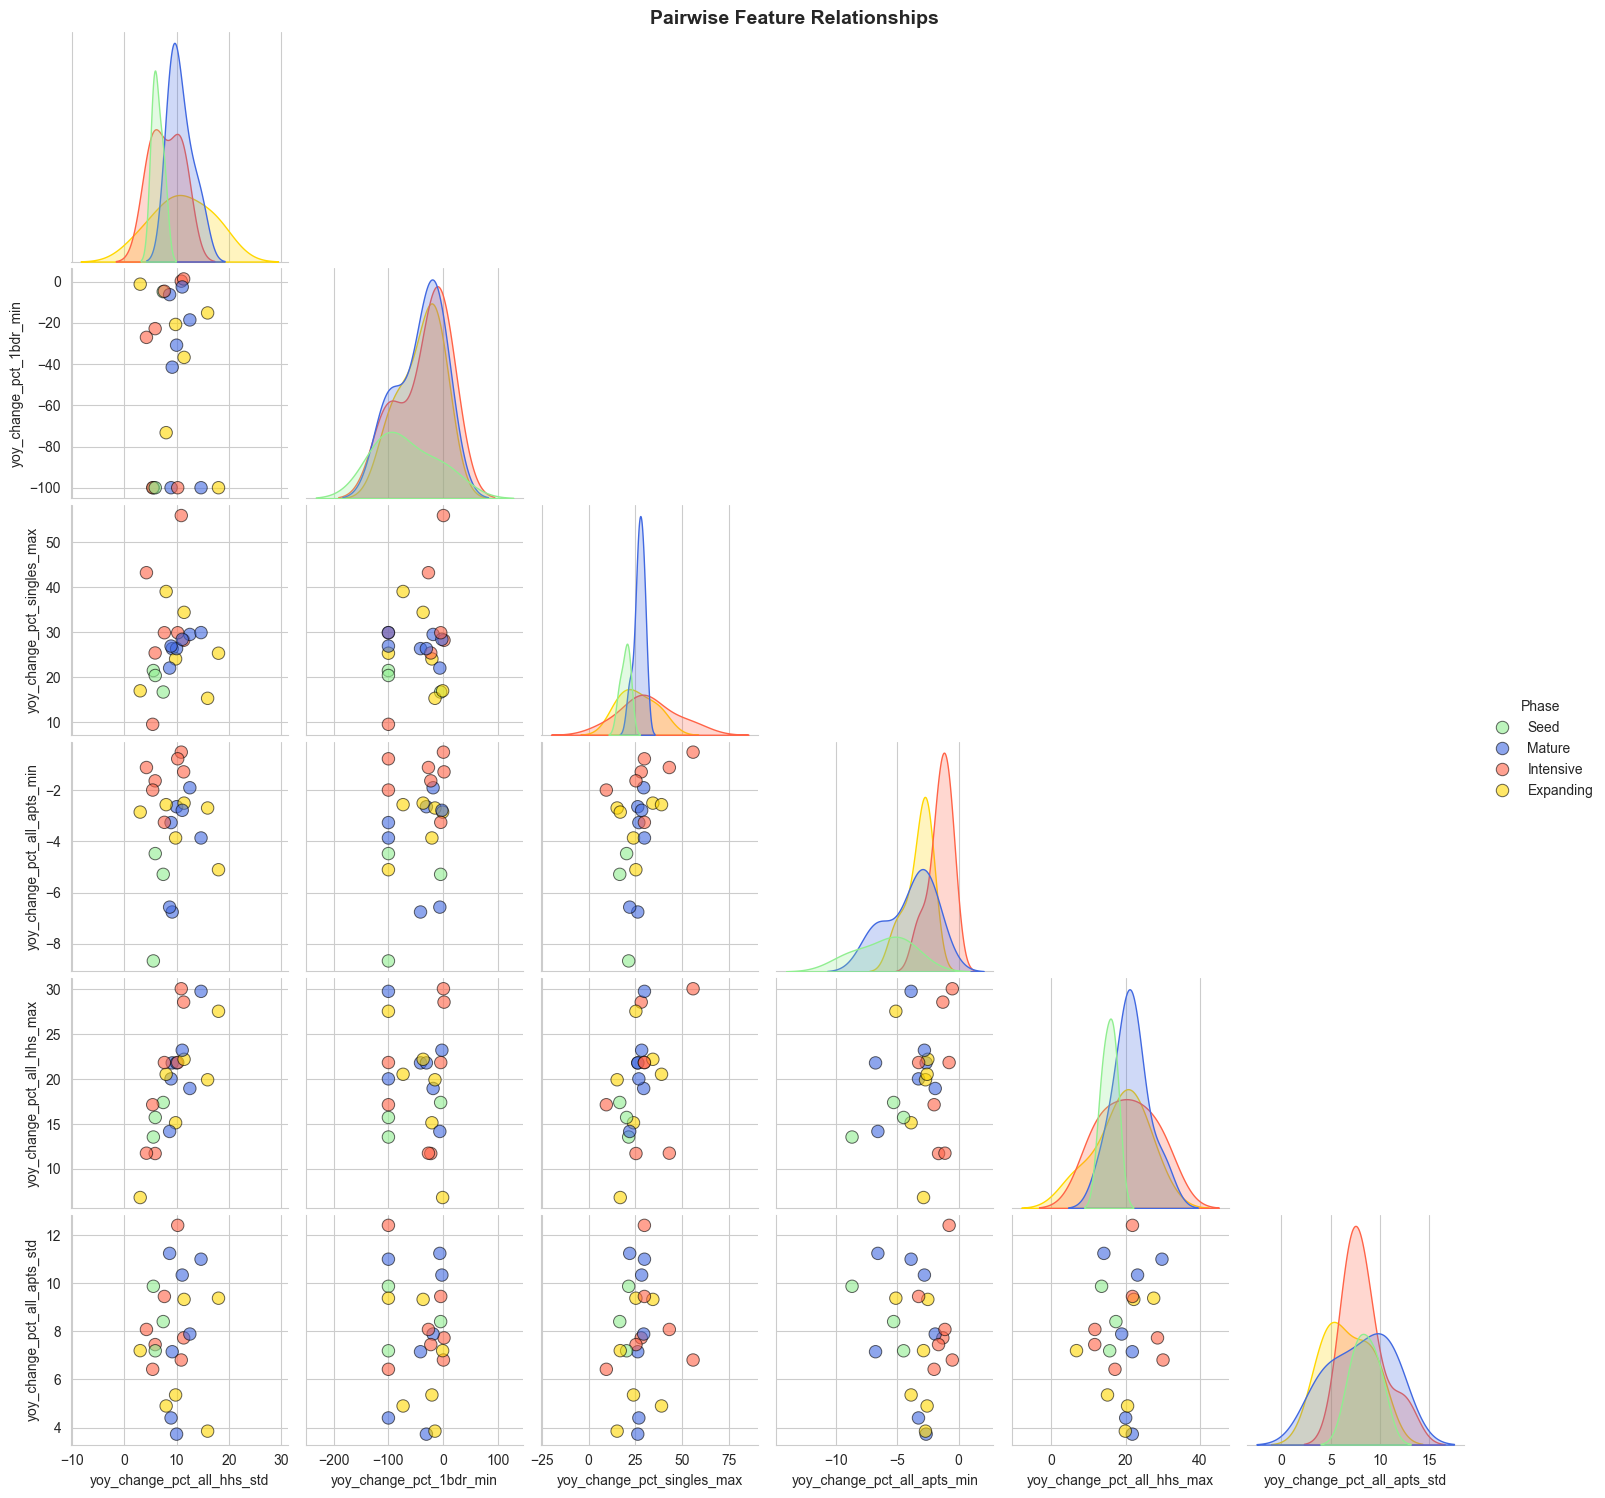

In [79]:
plot_scatter_matrix(results_df, important_df['feature'].iloc[:6].to_list())

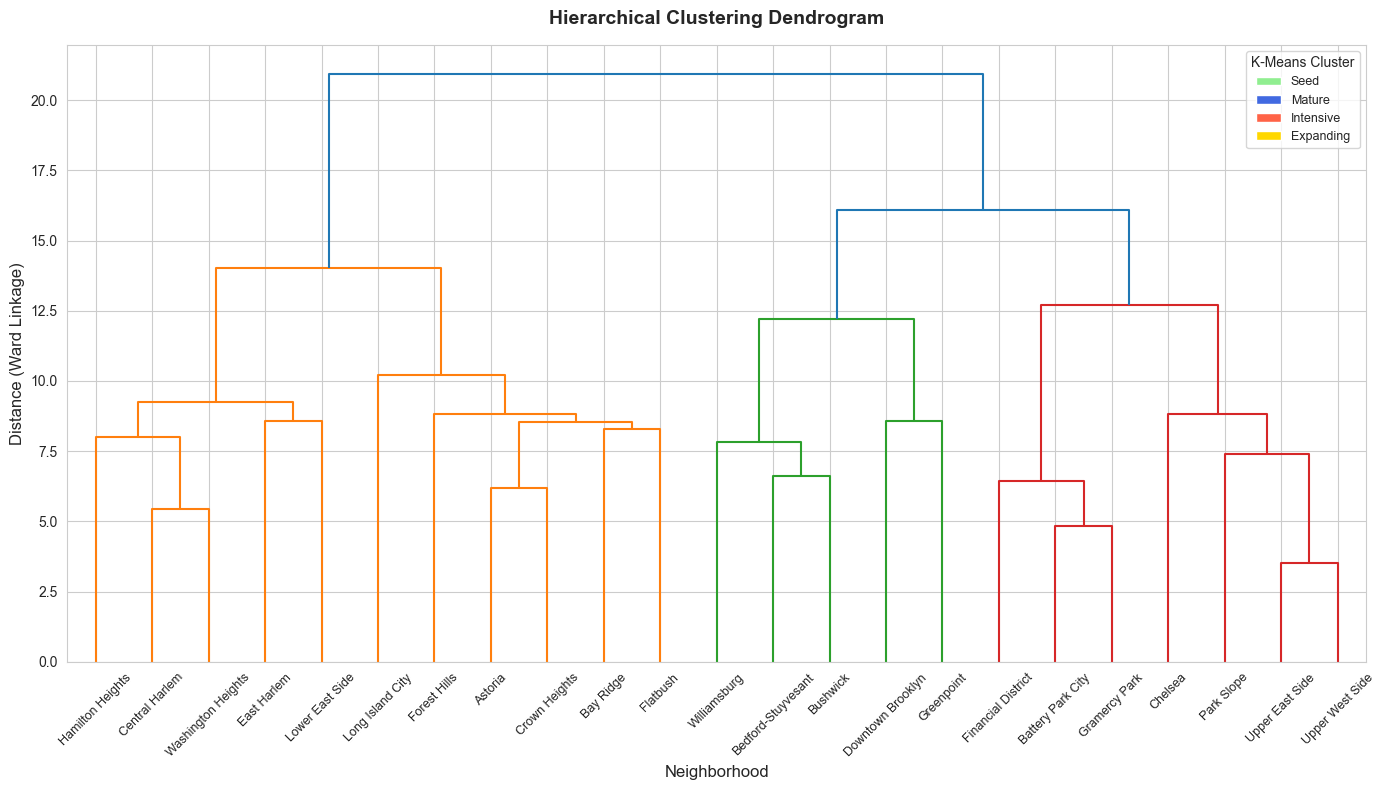

In [80]:
plot_dendrogram_analysis(x_scaled, y, neighborhoods)

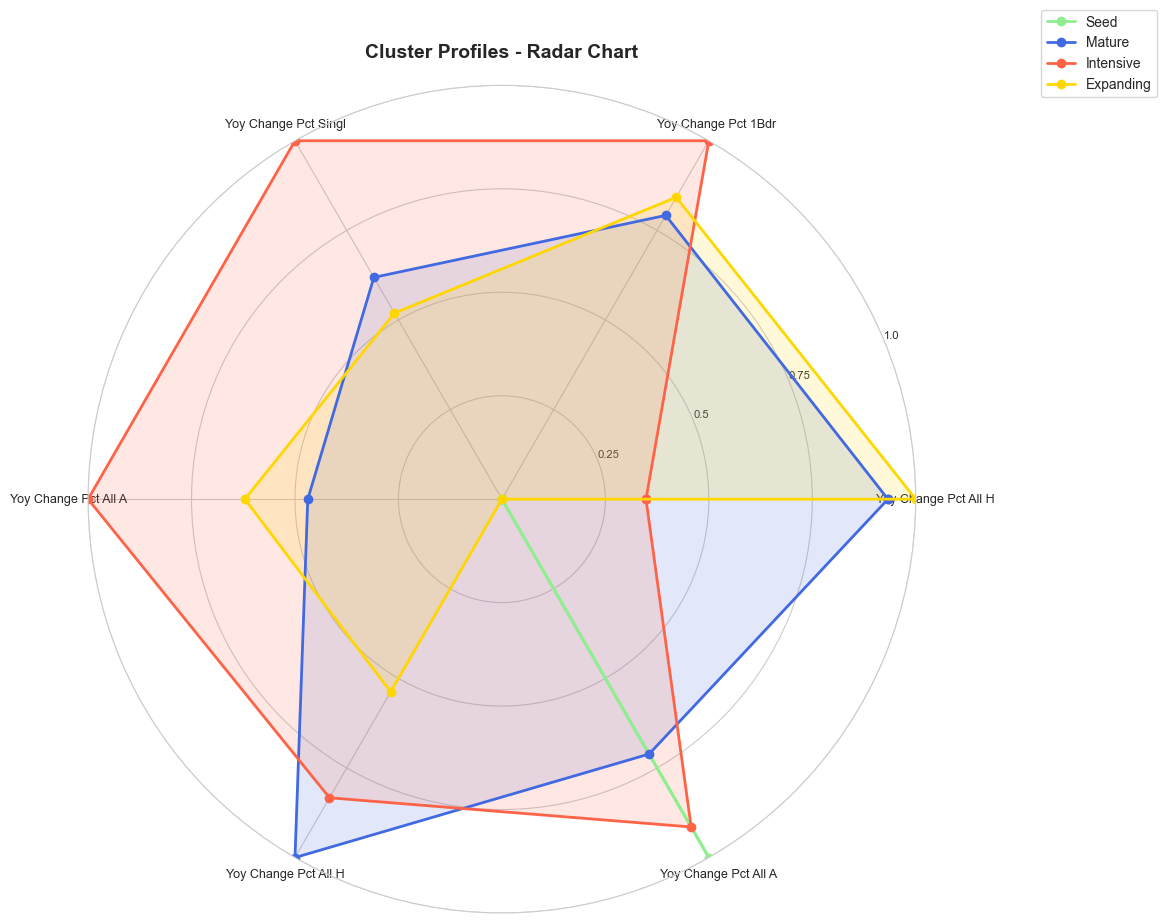

In [81]:
plot_radar_chart(results_df, important_df['feature'].iloc[:6].to_list())